In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np
import matplotlib.dates as mdates
import yaml

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools,interactive, utilities

In [2]:
importlib.reload(tools)
importlib.reload(plotting)

<module 'dissipationSML.plotting' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py'>

In [3]:
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"

thesis_resources_path = "/Users/tillmoritz/Desktop/Thesis_resources"

In [4]:
# Load YAML from a file
with open(yaml_path, 'r') as file:
    config = yaml.safe_load(file)

## 2. Create datasets for each glider mission containing MLD + other important variables for every profile

In [5]:
mld_list = []
binned_list = []
for glider in tqdm(config['gliders'], desc="Processing gliders"):
    glider_name = glider['name']
    
    for mission in glider['missions']:
        print(f"Processing glidermission: {mission['folder']}")
        folder = mission.get('folder')
        if folder == 'no folder':
            continue

        file_path = f"{destination_folder}/{folder}/mld_CR1.nc"
        mld_ds = xr.open_dataset(file_path)
        binned_ds = xr.open_dataset(f"{destination_folder}/{folder}/dissipation_binned.nc")
        binned_ds['DISSIPATION_LEM'] = binned_ds['DISSIPATION_LEM'].where(binned_ds['DISSIPATION_LEM'] > 5e-11, np.nan)

        ### add the global attributes from binned to mld
        for attr in binned_ds.attrs:
            mld_ds.attrs[attr] = binned_ds.attrs[attr]
        mld_list.append(mld_ds)
        binned_list.append(binned_ds)

Processing gliders:  11%|█         | 1/9 [00:00<00:01,  7.89it/s]

Processing glidermission: 005/20080606
Processing glidermission: 005/20090829
Processing glidermission: 005/20081106
Processing glidermission: 012/20070831
Processing glidermission: 014/20080829
Processing glidermission: 016/20071113


Processing gliders:  44%|████▍     | 4/9 [00:00<00:00, 14.98it/s]

Processing glidermission: 016/20080607
Processing glidermission: 016/20090605
Processing glidermission: 101/20070609
Processing glidermission: 101/20081108
Processing glidermission: no folder
Processing glidermission: 102/20071113
Processing glidermission: no folder
Processing glidermission: 103/20070218
Processing glidermission: 103/20071113


Processing gliders: 100%|██████████| 9/9 [00:00<00:00, 17.13it/s]

Processing glidermission: 103/20090223
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: 104/20070901
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder
Processing glidermission: no folder


In [6]:
bathymetry = xr.open_dataset("/Users/tillmoritz/Desktop/Master_thesis/Data/Bathymetry/GEBCO_2024_IFR.nc")
for mld_ds in mld_list:
    mld_ds['CAST'] = (np.ceil(mld_ds.PROFILE_NUMBER/2)).astype(int)
    lon = mld_ds.LONGITUDE
    lat = mld_ds.LATITUDE
    elevation = bathymetry['elevation'].sel(lon=lon, lat=lat, method='nearest')
    mld_ds['BATHYMETRY'] = elevation
### add the bathymetry to the binned and mld datasets
for ds in binned_list:
    lon = ds.LONGITUDE
    lat = ds.LATITUDE
    elevation = bathymetry['elevation'].sel(lon=lon, lat=lat, method='nearest')
    ds['BATHYMETRY'] = elevation

In [7]:
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.ticker as mticker

plotting_style = "/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle"
def get_bathymetry_levels(bath, level_spacing=250):
        """
        This function computes the bathymetry levels for a given bathymetry dataset.

        Parameters
        ----------
        bath: xarray.Dataset
            Bathymetry dataset with 'elevation' variable.
        level_spacing: int, optional
            The spacing between contour levels. Default is 250 m.

        Returns
        -------
        levels: numpy.ndarray
            An array of bathymetry levels.
        contour_levels: numpy.ndarray
            An array of contour levels.
        max_level: int
            The maximum bathymetry level.
        """
        max_depth = np.max(-bath.elevation.values)  # Depths are negative
        max_level = level_spacing * (np.round(max_depth / level_spacing) + 1)
        levels = np.arange(0, max_level, level_spacing)
        contour_levels = levels[::2]  # Every second level
        return levels, contour_levels, max_level

def get_var_styles(var_list):
    """Return line, marker, and color styles for a list of variables."""
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', '*', 'x', '^']
    colors = ['tab:blue', 'tab:orange', 'tab:gray', 'tab:cyan']
    return (
        {var: linestyles[i % len(linestyles)] for i, var in enumerate(var_list)},
        {var: markers[i % len(markers)] for i, var in enumerate(var_list)},
        {var: colors[i % len(colors)] for i, var in enumerate(var_list)}
    )

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.ticker as mticker

plotting_style = "/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle"

def plot_glider_track(ds, mean_after="Profile", ax=None, **kw):
    """
    Plot glider track(s) on a map.

    If ds is a single Dataset: scatter is colored by TIME.
    If ds is a list of Datasets: each dataset is one mission, colored by mission.

    Parameters
    ----------
    ds : xarray.Dataset or list of xarray.Dataset
        Dataset(s) with LATITUDE, LONGITUDE, TIME, GLIDER, MISSION.
    mean_after : {"Profile", "Cast", "None"}, default="Profile"
        Whether to average lat/lon/time per profile, per cast, or use raw values.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on. If None, a new figure/axis is created.
    **kw : dict
        Extra keyword arguments passed to ax.scatter.

    Returns
    -------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
    """

    map_kw = ccrs.PlateCarree()

    with plt.style.context(plotting_style):
        if ax is None:
            fig, ax = plt.subplots(subplot_kw={"projection": map_kw}, figsize=(8, 6))
        else:
            fig = plt.gcf()

        # Define bounding box
        lon_min, lon_max = -15, -6
        lat_min, lat_max = 61, 65

        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=map_kw)
        ax.set_aspect("auto")

        # Bathymetry (assuming bathymetry is global variable)
        bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        levels, contour_levels, max_level = get_bathymetry_levels(bath)

        # --- Bathymetry background ---
        bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        levels, contour_levels, max_level = get_bathymetry_levels(bath)
        base_cmap = plt.get_cmap("Greys")
        cmap_bath = mcolors.LinearSegmentedColormap.from_list(
            "dark_greys", base_cmap(np.linspace(0.15, 0.9, len(levels)))
        )

        # Make a discrete normalization based on your levels
        norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_bath.N)

        # Plot with levels + colormap
        pcm = ax.pcolormesh(
            bath.lon, bath.lat, abs(bath.elevation.values),
            cmap=cmap_bath, norm=norm, transform=ccrs.PlateCarree(), zorder=1
        )

        # Single dataset → color by TIME
        if isinstance(ds, xr.Dataset):
            if mean_after == "Profile":
                latitudes = ds.LATITUDE.groupby(ds.PROFILE_NUMBER).mean().values
                longitudes = ds.LONGITUDE.groupby(ds.PROFILE_NUMBER).mean().values
                times = ds.TIME.groupby(ds.PROFILE_NUMBER).mean().values
            elif mean_after == "Cast":
                latitudes = ds.LATITUDE.groupby(ds.CAST).mean().values
                longitudes = ds.LONGITUDE.groupby(ds.CAST).mean().values
                times = ds.TIME.groupby(ds.CAST).mean().values
            else:
                latitudes = ds.LATITUDE.values
                longitudes = ds.LONGITUDE.values
                times = ds.TIME.values

            sc = ax.scatter(longitudes, latitudes, c=times, cmap="inferno", s=10, marker="o", **kw)

            # Time colorbar
            cbar = plt.colorbar(sc, ax=ax, pad=0.01, shrink=1)
            cbar.ax.set_yticklabels([pd.to_datetime(t).strftime("%Y-%b-%d") for t in cbar.get_ticks()])

        # List of datasets → color by mission
        elif isinstance(ds, list):
            def mission_label(dsi):
                return f"{dsi.attrs.get('Glider', 'Unknown')} - {dsi.attrs.get('Mission', 'Unknown')}"

            # Build (label, date) pairs
            mission_info = []
            for dsi in ds:
                label = mission_label(dsi)
                date = pd.to_datetime(dsi.TIME.min().values)  # mission start time
                mission_info.append((label, date))

            # Sort missions by date
            mission_info = sorted(mission_info, key=lambda x: x[1])
            mission_labels = [lab for lab, _ in mission_info]

            # Colormap
            mission_cmap = cm.get_cmap("inferno", len(mission_labels))
            mission_color_dict = {lab: mission_cmap(i) for i, lab in enumerate(mission_labels)}

            # Plot each mission
            for dsi, (label, _) in zip(ds, mission_info):
                if mean_after == "Profile":
                    latitudes = dsi.LATITUDE.groupby(dsi.PROFILE_NUMBER).mean().values
                    longitudes = dsi.LONGITUDE.groupby(dsi.PROFILE_NUMBER).mean().values
                elif mean_after == "Cast":
                    latitudes = dsi.LATITUDE.groupby(dsi.CAST).mean().values
                    longitudes = dsi.LONGITUDE.groupby(dsi.CAST).mean().values
                else:
                    latitudes = dsi.LATITUDE.values
                    longitudes = dsi.LONGITUDE.values

                ax.scatter(
                    longitudes, latitudes,
                    color=mission_color_dict[label], s=10, marker="o", label=label, **kw
                )

        # Colorbar with mission order by date
        norm = mcolors.BoundaryNorm(np.arange(len(mission_labels) + 1) - 0.5, mission_cmap.N)
        sm = plt.cm.ScalarMappable(cmap=mission_cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(
            sm, ax=ax, pad=0.01, shrink=1, ticks=np.arange(len(mission_labels))
        )
        cbar.ax.set_yticklabels(mission_labels)

        # Bathymetry colorbar
        #cbar_bath = plt.colorbar(pcm, ax=ax, label="Depth (m)", pad=0.01, shrink=1)
        #cbar_bath.set_ticks(levels)

        # Features
        ax.add_feature(cfeature.LAND, color="gray", zorder=10)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)

        # Labels & title
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title("Glider Track with Bathymetry")

        # Gridlines with custom ticks
        gl = ax.gridlines(draw_labels=True, color="black", alpha=0.5, linestyle="--")
        gl.xlocator = mticker.FixedLocator([-14, -12, -10, -8, -6])
        gl.ylocator = mticker.FixedLocator([61, 62, 63, 64, 65])
        gl.top_labels = False
        gl.right_labels = False

    return fig, ax


In [9]:
def plot_glider_density_by_mission(ds_list, mean_after="Profile", ax=None, bins=50, **kw):
    """
    Plot dive density as circles representing N dives, colored by number of missions.

    Each circle corresponds to one spatial bin containing dives from possibly multiple missions.
    The circle is located at the mean latitude/longitude of dives in that bin.
    The color indicates the number of missions contributing to that bin.

    Parameters
    ----------
    ds_list : list of xarray.Dataset
        Each dataset has LATITUDE, LONGITUDE, PROFILE_NUMBER or CAST, plus attributes
        'Mission' and 'Glider' (optional).
    mean_after : {"Profile", "Cast", "None"}, default="Profile"
        Whether to average lat/lon per profile, per cast, or use raw values.
    ax : matplotlib.axes.Axes, optional
        Axis to plot on.
    bins : int, default=100
        Number of bins for the histogram.
    **kw : dict
        Extra keyword arguments passed to ax.scatter.

    Returns
    -------
    fig, ax
    """

    map_kw = ccrs.PlateCarree()

    with plt.style.context(plotting_style):
        if ax is None:
            fig, ax = plt.subplots(subplot_kw={"projection": map_kw}, figsize=(10, 6))
        else:
            fig = plt.gcf()

        # Bounding box
        lon_min, lon_max = -15, -6
        lat_min, lat_max = 61, 65
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=map_kw)
        ax.set_aspect("auto")

        # Bathymetry background
        bath = bathymetry.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        levels, contour_levels, max_level = get_bathymetry_levels(bath, level_spacing=250)
        print(levels)
        base_cmap = plt.get_cmap("Greys")
        cmap_bath = mcolors.LinearSegmentedColormap.from_list(
            "dark_greys", base_cmap(np.linspace(0.15, 0.9, len(levels)))
        )
        norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap_bath.N)
        ax.pcolormesh(
            bath.lon, bath.lat, abs(bath.elevation.values),
            cmap=cmap_bath, norm=norm, transform=ccrs.PlateCarree(), zorder=1
        )
        ### add contour lines every 500m
        cs = ax.contour(
            bath.lon, bath.lat, abs(bath.elevation.values),
            levels=contour_levels, colors='black', linewidths=0.5,
            transform=ccrs.PlateCarree(), zorder=1, alpha=0.35
        )

        # Collect all dives with mission info
        all_data = []
        for i, ds in enumerate(ds_list):
            if mean_after == "Profile":
                lats = ds.LATITUDE.groupby(ds.PROFILE_NUMBER).mean().values
                lons = ds.LONGITUDE.groupby(ds.PROFILE_NUMBER).mean().values
            elif mean_after == "Cast":
                lats = ds.LATITUDE.groupby(ds.CAST).mean().values
                lons = ds.LONGITUDE.groupby(ds.CAST).mean().values
            else:
                lats = ds.LATITUDE.values
                lons = ds.LONGITUDE.values

            mission_name = ds.attrs.get("Mission", f"Mission_{i+1}")
            all_data.append(pd.DataFrame({
                "lat": lats,
                "lon": lons,
                "mission": mission_name
            }))

        df = pd.concat(all_data, ignore_index=True)

        # Bin dives spatially
        lat_bins = np.linspace(lat_min, lat_max, bins)
        lon_bins = np.linspace(lon_min, lon_max, bins)
        df["lat_bin"] = pd.cut(df["lat"], bins=lat_bins)
        df["lon_bin"] = pd.cut(df["lon"], bins=lon_bins)

        # Group by bin and compute:
        # - mean lat/lon for circle position
        # - number of dives
        # - number of unique missions
        grouped = (
            df.groupby(["lat_bin", "lon_bin"])
              .agg(
                  lat_mean=("lat", "mean"),
                  lon_mean=("lon", "mean"),
                  n_dives=("lat", "count"),
                  n_missions=("mission", pd.Series.nunique),
              )
              .dropna(subset=["lat_mean", "lon_mean"])
        )

        # --- Discrete colormap for missions ---
        n_levels = int(grouped["n_missions"].max())
        cmap = plt.get_cmap("Reds", n_levels)
        norm = mcolors.BoundaryNorm(np.arange(0.5, n_levels + 1.5, 1), n_levels)

        sc = ax.scatter(
            grouped["lon_mean"], grouped["lat_mean"],
            c=grouped["n_missions"], cmap=cmap, norm=norm,
            s=grouped["n_dives"]*2, edgecolor="black", linewidth=0.3, alpha=0.8,
            transform=ccrs.PlateCarree(), **kw
        )

        # --- Colorbar ---
        cbar = plt.colorbar(sc, ax=ax, pad=0.01, shrink=1, ticks=np.arange(1, n_levels + 1))
        cbar.set_label("Number of Missions")

        # Add a legend for marker sizes (number of dives)
        for dives in [10, 50, 100, 200]:  # example reference values
            ax.scatter([], [], c='red', alpha=0.5, s=dives*2,  # same size scaling as above
                        label=f'{dives} profiles', edgecolor='black', linewidth=0.3)

        # Place the legend (adjust loc or bbox_to_anchor as needed)
        leg = ax.legend(scatterpoints=1, frameon=True, labelspacing=1, loc='lower left', fontsize = 10)#, bbox_to_anchor=(1.2, 0.0))
        leg.get_frame().set_facecolor('none')
        leg.get_frame().set_edgecolor('none')

        # Features
        ax.add_feature(cfeature.LAND, color="gray", zorder=10)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=11)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        #ax.set_title("Dive Density (Circle = N dives, Color = Missions)")

        # Gridlines
        gl = ax.gridlines(draw_labels=True, color="black", alpha=0.5, linestyle="--")
        gl.xlocator = mticker.FixedLocator([-14, -12, -10, -8, -6])
        gl.ylocator = mticker.FixedLocator([61, 62, 63, 64, 65])
        gl.top_labels = False
        gl.right_labels = False

    return fig, ax


In [10]:
### cut all mld datasets to IFR
import importlib
importlib.reload(tools)
import regionmask as rm
def cut_region(ds: xr.Dataset, region: rm.Regions, region_number: int = 0) -> xr.Dataset:
    """
    Cut an xarray dataset to a region specified by a regionmask region.
    """
    lon_name = "longitude" if "longitude" in ds.coords else "LONGITUDE"
    lat_name = "latitude" if "latitude" in ds.coords else "LATITUDE"

    # Create region mask
    region_mask = region.mask(ds[lon_name], ds[lat_name])

    # Apply mask to dataset

    ds_region = ds.isel(TIME=region_mask == region_number)

    return ds_region

def cut_all_to_region(mld_list, binned_list, region, region_number=0):
    """
    Cuts all datasets in mld_list and binned_list to the specified region.
    """
    mld_list_region = []
    binned_list_region = []

    for mld_ds, binned_ds in zip(mld_list, binned_list):
        mld_IFR = cut_region(mld_ds, region, region_number)
        binned_IFR = cut_region(binned_ds, region, region_number)

        # only keep datasets that have at least one TIME entry
        if "TIME" in mld_IFR.dims and mld_IFR.sizes["TIME"] > 0:
            mld_list_region.append(mld_IFR)
            binned_list_region.append(binned_IFR)

    return mld_list_region, binned_list_region


In [11]:
coords = [[-14.0, 61], # First corner
            [-14, 65], # Second corner
            [-6.5, 65], # Third corner
            [-6.5, 61]] # Fourth corner

IFR_msk = rm.Regions([coords], names=['IFR'])

mld_list_IFR, binned_list_IFR = cut_all_to_region(mld_list, binned_list, IFR_msk, 0)


In [12]:
total_number = 0
for mld in mld_list_IFR:
    ### print the number of profiles for which MLD is not nan
    num_profiles = np.sum(~np.isnan(mld['MLD'].values))
    total_number += num_profiles
    print(f"Number of profiles with valid MLD in {mld.attrs['Glider']+ mld.attrs['Mission']}: {num_profiles}")

Number of profiles with valid MLD in 00520080606: 669
Number of profiles with valid MLD in 00520090829: 916
Number of profiles with valid MLD in 00520081106: 166
Number of profiles with valid MLD in 01220070831: 369
Number of profiles with valid MLD in 01420080829: 787
Number of profiles with valid MLD in 01620071113: 409
Number of profiles with valid MLD in 01620080607: 682
Number of profiles with valid MLD in 01620090605: 539
Number of profiles with valid MLD in 10120070609: 905
Number of profiles with valid MLD in 10120081108: 652
Number of profiles with valid MLD in 10220071113: 882
Number of profiles with valid MLD in 10320070218: 1267
Number of profiles with valid MLD in 10320071113: 773
Number of profiles with valid MLD in 10320090223: 874
Number of profiles with valid MLD in 10420070901: 738


In [13]:
total_number

np.int64(10628)

In [14]:
coords_NSW = [[-12, 64.5], # First corner
            [-11, 65.3], # Second corner
            [-7, 63.8], # Third corner
            [-8, 63]] # Fourth corner
coords_FBC = [[-10, 61.5], # First corner
            [-9, 62.2], # Second corner
            [-7.4, 61.8], # Third corner
            [-8.4, 61.1]] # Fourth corner
coords_ALW = [[-14, 62.8], # First corner
            [-13, 63.5], # Second corner
            [-9.4, 62.5], # Third corner
            [-10.4, 61.8]] # Fourth corner
coords_WVJ = [[-13.9, 63.8], # First corner
            [-13.1, 64.2], # Second corner
            [-12.2, 64], # Third corner
            [-13.0, 63.6]] # Fourth corner

NSW_msk = rm.Regions([coords_NSW], names=['NSW'])
FBC_msk = rm.Regions([coords_FBC], names=['FBC'])
ALW_msk = rm.Regions([coords_ALW], names=['ALW'])
WVJ_msk = rm.Regions([coords_WVJ], names=['WVJ'])

In [15]:
# Define your polygons
coords_sec1 = [[-14, 63], # First corner
            [-12.3, 63], # Second corner
            [-8.7, 62], # Third corner
            [-9.0, 61.7]] # Fourth corner
coords_sec2 = [[-13.6, 64.0], # First corner
            [-12.8, 64.0], # Second corner
            [-12.8, 63], # Third corner
            [-13.6, 63]] # Fourth corner

In [16]:
# Create the regions
sec_msk = rm.Regions([coords_sec1, coords_sec2],names=['Section 1', 'Section 2'])
# Make sure to create 2D lon/lat grids if your bathymetry coords are 1D
lon2d, lat2d = np.meshgrid(bathymetry.lon, bathymetry.lat)
# Apply mask_3D
mask3d = sec_msk.mask_3D(lon2d, lat2d)
# Combine multiple regions (logical OR along the region axis)
mask_combined = mask3d.any(dim="region")   # True if inside ANY region
### rename dims name from lat_idx to lat and lon_idx to lon
mask_combined = mask_combined.rename({"lat_idx": "lat", "lon_idx": "lon"})
# Apply mask to bathymetry
bath_sec = bathymetry.where(mask_combined, drop=True)

In [17]:
mld_list_sec1, binned_list_sec1 = cut_all_to_region(mld_list_IFR, binned_list_IFR, sec_msk, 0)
mld_list_sec2, binned_list_sec2 = cut_all_to_region(mld_list_IFR, binned_list_IFR, sec_msk, 1)
mld_list_sec = mld_list_sec1 + mld_list_sec2
binned_list_sec = binned_list_sec1 + binned_list_sec2

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])


In [18]:
### Only keep profiles that have a mean depth shallower between 740m and 760m
mld_list_sec_750 = []
binned_list_sec_750 = []

bath_min, bath_max = -800, -700

for mld_ds in mld_list_sec:
    # only keep datasets that have at least one TIME entry
    mld_ds_750 = mld_ds.where((mld_ds.BATHYMETRY <= bath_max) & (mld_ds.BATHYMETRY >= bath_min), drop=True)
    if "TIME" in mld_ds_750.dims and mld_ds_750.sizes["TIME"] > 0:
        mld_list_sec_750.append(mld_ds_750)
    
for binned_ds in binned_list_sec:
    # Compute mean bathymetry per profile (vectorized)
    # Promote PROFILE_NUMBER to a coordinate
    binned_ds = binned_ds.set_coords('PROFILE_NUMBER')

    mean_bathy_per_profile = binned_ds['BATHYMETRY'].groupby('PROFILE_NUMBER').mean(dim='TIME')
    
    # Keep only profiles within the bathymetry range
    profiles_to_keep = mean_bathy_per_profile.where(
        (mean_bathy_per_profile >= bath_min) & (mean_bathy_per_profile <= bath_max)
    ).dropna('PROFILE_NUMBER').PROFILE_NUMBER.values
    
    if profiles_to_keep.size == 0:
        continue
    
    # Filter dataset by the selected profiles using sel (fast)
    binned_ds_750 = binned_ds.sel(TIME=binned_ds['PROFILE_NUMBER'].isin(profiles_to_keep))
    
    # Only append if TIME exists and has size > 0
    if binned_ds_750.sizes["TIME"] > 0:
        binned_list_sec_750.append(binned_ds_750)

In [19]:
import numpy as np

tolerance = 0  # meters, optional if exact match may miss points

# bath_sec['elevation'] assumed to be 2D: (lat, lon) or (y, x)
mask = np.abs(bath_sec['elevation'].values + 750) <= tolerance  # points near -750

# Extract lon and lat arrays at those points
lon_vals = bath_sec['lon'].values
lat_vals = bath_sec['lat'].values

# If lon/lat are 2D arrays (meshgrid)
if lon_vals.ndim == 2:
    lon_sel = lon_vals[mask]
    lat_sel = lat_vals[mask]
else:
    # if 1D, need to meshgrid first
    LON, LAT = np.meshgrid(lon_vals, lat_vals)
    lon_sel = LON[mask]
    lat_sel = LAT[mask]

# Combine into Nx2 array
path_coordinates = np.column_stack((lon_sel, lat_sel))
### sort path coordinates the other way around so that it goes from NW to SE
path_coordinates = path_coordinates[np.argsort(path_coordinates[:, 1])[::-1]]


In [20]:
### first filter the coordinates by applying a sorting algorithm and then binning
### so that the equal distant track can then be calculated
path = np.array(path_coordinates)

# Split the path into three logical masks
mask1 = path[:, 1] > 63.9
mask2 = (path[:, 1] <= 63.9) & (path[:, 1] > 62.75)
mask3 = path[:, 1] <= 62.75

# Sort each segment according to its rule
seg1 = path[mask1][np.argsort(path[mask1][:, 0])]                  # lon ascending
seg2 = path[mask2][np.argsort(-path[mask2][:, 1])]                 # lat descending
seg3 = path[mask3][np.argsort(path[mask3][:, 0])]                  # lon ascending

# Concatenate in the correct order
sorted_path = np.vstack((seg1, seg2, seg3))

path = np.array(sorted_path)
n_bins = len(path)/3  # 

# split path into bins of roughly equal length
bins = np.array_split(path, n_bins)
filtered_coords = np.array([[b[:,0].mean(), b[:,1].mean()] for b in bins])

In [21]:
import numpy as np
from geopy.distance import geodesic
from scipy.interpolate import interp1d

# path_coordinates is an Nx2 array: [lon, lat]

# Compute cumulative distance along the path (in km)
distances = [0.0]
for i in range(1, len(filtered_coords)):
    d = geodesic(
        (filtered_coords[i-1][1], filtered_coords[i-1][0]),  # (lat, lon)
        (filtered_coords[i][1], filtered_coords[i][0])
    ).km
    distances.append(distances[-1] + d)

distances = np.array(distances)

# Define equally spaced distance values
distance = 5
dist_new = np.arange(0, distances[-1], distance)

# Interpolate lon and lat separately along the distance
lon_interp = interp1d(distances, filtered_coords[:,0], kind='linear')
lat_interp = interp1d(distances, filtered_coords[:,1], kind='linear')

lon_new = lon_interp(dist_new)
lat_new = lat_interp(dist_new)

# Combined equally spaced coordinates
equal_spaced_coords = np.column_stack((lon_new, lat_new))

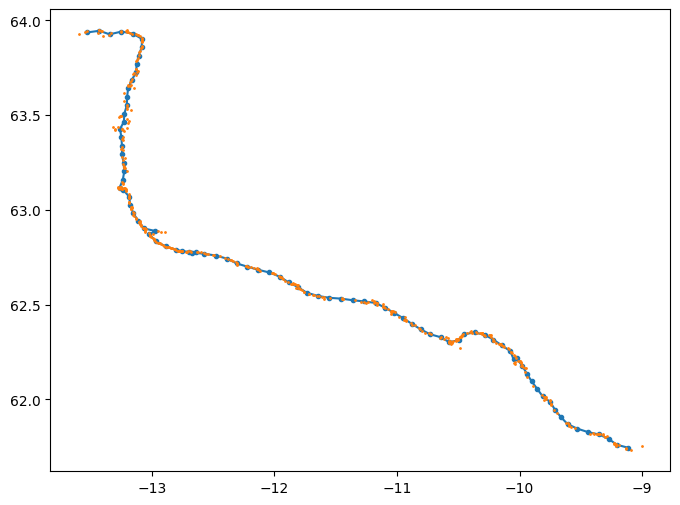

In [22]:
## plot the longitude and latitude of the path_coordinates
plt.figure(figsize=(8, 6))
plt.plot(equal_spaced_coords[:, 0], equal_spaced_coords[:, 1], 'o-', markersize=3)
plt.plot(path_coordinates[:, 0], path_coordinates[:, 1], label='Bathymetry Points', marker='.', linestyle='None', markersize=2)
#plt.plot(filtered_coords[:, 0], filtered_coords[:, 1], label='Original Points', marker='x', linestyle='None', markersize=3)
#plt.xlim(-13.3, -12.8)
plt.show()


In [23]:
## find the dataset of Glider = 005 and Mission: 20080606 both attributes in mld_list_IFR
target_glider = "005"
target_mission = "20080606"
target_ds = None
for ds in mld_list_IFR:
    if ds.attrs.get("Glider") == target_glider and ds.attrs.get("Mission") == target_mission:
        target_ds = ds
        break

In [24]:
target_ds = xr.open_dataset("/Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/dissipation_binned.nc")

In [25]:
target_ds['CAST'] = (np.ceil(target_ds.PROFILE_NUMBER/2)).astype(int)

[   0.  250.  500.  750. 1000. 1250. 1500. 1750. 2000. 2250. 2500. 2750.
 3000. 3250. 3500. 3750.]


/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/4017013973.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["lat_bin", "lon_bin"])


[-8.80435162] [62.24270646] 175
[] [] 120
[-10.92362456] [62.14967634] 220
[-9.59370274] [62.83229795] 280
[-8.0266824] [63.73388836] 340
[-6.62286629] [64.34278723] 365


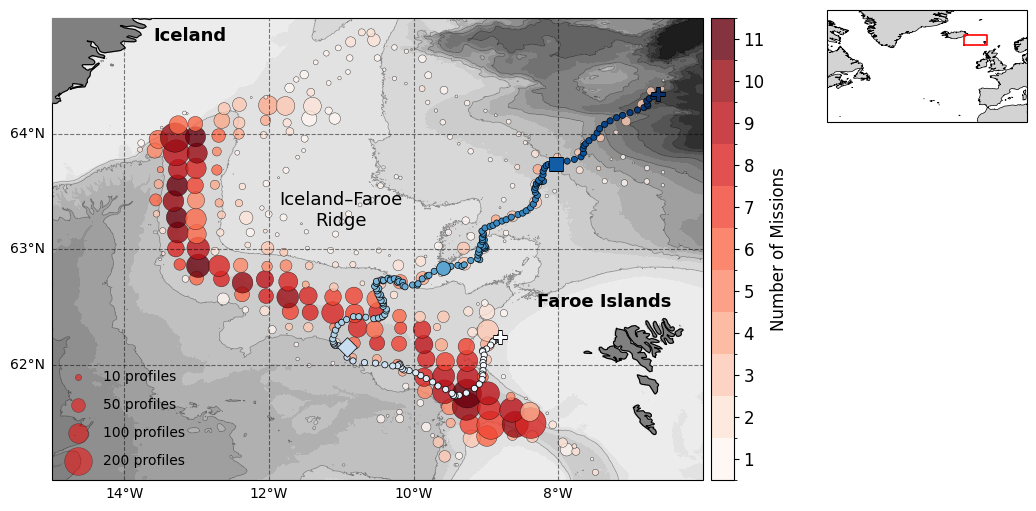

In [132]:
### plot a 10km filling around the contour line
from shapely.geometry import LineString
from shapely.ops import unary_union
from pyproj import Geod
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

with plt.style.context(plotting_style):
    fig, ax = plot_glider_density_by_mission(mld_list_IFR, mean_after="Profile", bins=30)
    ### plot the polygon inside the map and add small describtion
    """ax.add_patch(plt.Polygon(coords_FBC, closed=True, fill=None, edgecolor='black', linewidth=1, linestyle='--'))
    ax.text(coords_FBC[0][0]+0.2, coords_FBC[0][1], 'FBC', fontsize=10, weight='bold', color='black', transform=ccrs.PlateCarree())
    ax.add_patch(plt.Polygon(coords_NSW, closed=True, fill=None, edgecolor='black', linewidth=1,linestyle='--'))
    ax.text(coords_NSW[0][0]+0.2, coords_NSW[0][1], 'NSW', fontsize=10, weight='bold', color='black', transform=ccrs.PlateCarree())
    ax.add_patch(plt.Polygon(coords_ALW, closed=True, fill=None, edgecolor='black', linewidth=1,linestyle='--'))
    ax.text(coords_ALW[0][0]+0.2, coords_ALW[0][1], 'NAW', fontsize=10, weight='bold', color='black', transform=ccrs.PlateCarree())
    ax.add_patch(plt.Polygon(coords_WVJ, closed=True, fill=None, edgecolor='black', linewidth=1,linestyle='--'))
    ax.text(coords_WVJ[0][0]+0.2, coords_WVJ[0][1], 'WV', fontsize=10, weight='bold', color='black', transform=ccrs.PlateCarree())
    ax.plot(equal_spaced_coords[:, 0], equal_spaced_coords[:, 1], 'cornflowerblue', linewidth=3, transform=ccrs.PlateCarree())"""
    ### add the description Iceland and Faroe Islands to the map
    ax.text(-13.6, 64.8, 'Iceland', fontsize=13, weight='bold', color='black', transform=ccrs.PlateCarree(), zorder=100)
    ax.text(-8.3, 62.5, 'Faroe Islands', fontsize=13, weight='bold', color='black', transform=ccrs.PlateCarree(), zorder=100)
    ax.text(-11, 63.5, "Iceland–Faroe\nRidge",fontsize=13,color="black",ha="center",va="top",transform=ccrs.PlateCarree(),zorder=100)
    ### plot cooridinates sec1 and sec2
    #ax.add_patch(plt.Polygon(coords_sec1, closed=True, fill=None, edgecolor='black', linewidth=1, linestyle=':'))
    #ax.add_patch(plt.Polygon(coords_sec2, closed=True, fill=None, edgecolor='black', linewidth=1, linestyle=':'))
    

    ### plot the track of the target mission, each scatter point representing one Cast (group by Cast) and color by time
    if target_ds is not None:
        ### cut all casts before 180 and after 370
        ds_casts = target_ds.where((target_ds.CAST >= 175) & (target_ds.CAST <= 365), drop=True)
        latitudes = ds_casts.LATITUDE.groupby(ds_casts.CAST).mean().values
        longitudes = ds_casts.LONGITUDE.groupby(ds_casts.CAST).mean().values
        times = ds_casts.TIME.groupby(ds_casts.CAST).mean().values
        colors = cm.Blues((times - times.min()) / (times.max() - times.min()))
        casts = ds_casts.CAST.groupby(ds_casts.CAST).mean().values

        sc = ax.scatter(longitudes, latitudes, c=times, cmap="Blues", s=20, marker="o", edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree(), zorder=101)
        ### add starts and ends of the track
        casts_to_show = [int(casts.min()),120,220,280,340,int(casts.max())]
        cast_symbols = ["P","^","D","o","s", "P"]
        for cast, symbol in zip(casts_to_show, cast_symbols):
            idx = np.where(casts == cast)[0]
            ax.scatter(longitudes[idx], latitudes[idx], color=colors[idx], s=100, marker=symbol, edgecolor='black', linewidth=0.5, transform=ccrs.PlateCarree(), zorder=102)
            print(longitudes[idx], latitudes[idx], cast)

        #ax.legend(loc='upper right', fontsize=10)
        #fig.set_size_inches(8, 7) 
        leg = ax.legend(scatterpoints=1, frameon=True, labelspacing=1, loc='lower left', fontsize = 10)#, bbox_to_anchor=(1.2, 0.0)) #
        leg.get_frame().set_facecolor('none') 
        leg.get_frame().set_edgecolor('none')

    # --- Add inset map ---
    # create a rectangle in figure coordinates [left, bottom, width, height]
    inset_ax_position = [0.9, 0.7,0.2, 0.2]  # adjust to taste
    inset = fig.add_axes(inset_ax_position, projection=ccrs.PlateCarree())

    # Set extent of North Atlantic
    inset.set_extent([-70, 10, 30, 75], crs=ccrs.PlateCarree())

    # Add land and coastlines
    inset.add_feature(cfeature.LAND, facecolor="lightgray")
    inset.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # Draw red rectangle for main domain
    lon_min, lon_max = -15, -6
    lat_min, lat_max = 61, 65
    inset.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
            [lat_min, lat_min, lat_max, lat_max, lat_min],
            color="red", linewidth=1.2, transform=ccrs.PlateCarree())

    #inset.set_title("North Atlantic", fontsize=8)
fig.savefig('/Users/tillmoritz/Desktop/OSM/Map.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [133]:
import matplotlib.pyplot as plt
import numpy as np

def plot_contours(ds, var='SIGMA_T', levels=10, v_res=2, ax=None):
    """
    Plot contour lines of a variable against profile number and depth.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with variables 'DEPTH' and `var`.
    var : str, optional
        Variable to contour (default 'SIGMA_T').
    levels : int or list
        Number of contour levels (default 10) or concrete levels as a list.
    v_res : float, optional
        Vertical resolution for gridding (default 2).
    ax : matplotlib Axes, optional
        Axis to plot on. If None, a new figure is created.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    # Extract data
    depth = ds['DEPTH'].values
    profiles = ds['PROFILE_NUMBER'].values
    variable = ds[var].values

    # Build regular grid
    p = 1
    z = v_res
    varG, profG, depthG = utilities.construct_2dgrid(
        profiles, depth, variable, p, z, x_bin_center=False
    )

    # Make meshgrid for contouring
    #X, Y = np.meshgrid(profG, depthG)

    # Setup figure/axes
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 9))
    else:
        fig = ax.figure

    # Contour line plot
    cs = ax.contour(profG, depthG, varG, levels=levels, colors="k", linewidths=1)#, linestyle = '-.-')
    #ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
    # Invert depth axis (increasing downward)
    #ax.invert_yaxis()

    # Labels
    #ax.set_xlabel("Profile number")
    #ax.set_ylabel("Depth [m]")
    #ax.set_title(f"Contour plot of {var}")

    return fig, ax

In [134]:
### add CAST to ds_dissipation as profilenumber/2
target_ds

<xarray.Dataset> Size: 57MB
Dimensions:                     (TIME: 323230)
Coordinates:
  * TIME                        (TIME) datetime64[ns] 3MB 2008-06-06T18:08:56...
Data variables: (12/21)
    PROFILE_NUMBER              (TIME) float64 3MB 1.0 1.0 1.0 ... 772.0 772.0
    DEPTH                       (TIME) float64 3MB 1.545 3.862 ... 3.971 1.706
    LONGITUDE                   (TIME) float64 3MB ...
    VELOCITY_SCALE_2_LOG        (TIME) float64 3MB ...
    VERTICAL_WATER_VELOCITY_HP  (TIME) float64 3MB ...
    VELOCITY_SCALE              (TIME) float64 3MB ...
    ...                          ...
    DISSIPATION_LEM             (TIME) float64 3MB nan nan nan ... nan nan nan
    DISSIPATION_LEM_LOG         (TIME) float64 3MB ...
    SORTED_N                    (TIME) float64 3MB ...
    SORTED_N2_LOG               (TIME) float64 3MB ...
    SORTED_N_LOG                (TIME) float64 3MB ...
    CAST                        (TIME) int64 3MB 1 1 1 1 1 ... 386 386 386 386
Attributes: (12/44)
    title:                                      OceanGliders trajectory file
    id:                                         sg005_20080606T180738_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    disclaimer:                                 Data provided AS-IS.
    Glider:                                     005
    Mission:                                    20080606
    binning:                                    mean of each profile
    binning_method:                             mean
    c_epsilon:                                  0.074

In [135]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)
importlib.reload(utilities)

<module 'dissipationSML.utilities' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/utilities.py'>

In [136]:
casts_to_show

[175, 120, 220, 280, 340, 365]

In [137]:
casts

array([175., 176., 177., 178., 179., 180., 181., 182., 183., 184., 185.,
       186., 187., 188., 189., 190., 191., 192., 193., 194., 195., 196.,
       197., 198., 199., 200., 201., 202., 203., 204., 205., 206., 207.,
       208., 209., 210., 211., 212., 213., 214., 215., 216., 217., 218.,
       219., 220., 221., 222., 223., 224., 225., 226., 227., 228., 229.,
       230., 231., 232., 233., 234., 235., 236., 237., 238., 239., 240.,
       241., 242., 243., 244., 245., 246., 247., 248., 249., 250., 251.,
       252., 253., 254., 255., 256., 257., 258., 259., 260., 261., 262.,
       263., 264., 265., 266., 267., 268., 269., 270., 271., 272., 273.,
       274., 275., 276., 277., 278., 279., 280., 281., 282., 283., 284.,
       285., 286., 287., 288., 289., 290., 291., 292., 293., 294., 295.,
       296., 297., 298., 299., 300., 301., 302., 303., 304., 305., 306.,
       307., 308., 309., 310., 311., 312., 313., 314., 315., 316., 317.,
       318., 319., 320., 321., 322., 323., 324., 32

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/2331871699.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[-1].scatter(casts*2, np.full_like(casts,1000), c=colors, cmap="Blues", s=20, marker="o", edgecolor='black', linewidth=0.5, zorder=104,clip_on=False,)


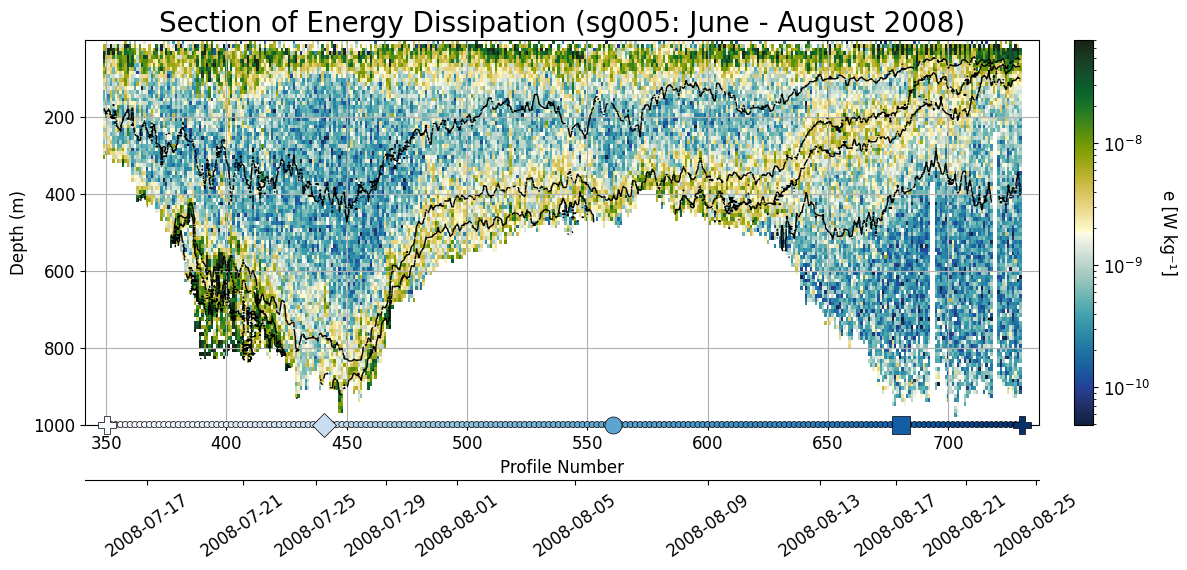

In [138]:
start = None#180 * 2
end = None#370 * 2
#levels_e = [-6.6,-7.0,-7.4,-7.8,-8.2,-8.6,-9.0,-9.4,-9.8,-10.2]
fig, axs = plotting.plot_section(ds_casts, vars=['DISSIPATION_LEM'], v_res=10, start=start, end=end, levels = False, log_scale=True)
axs[-1].scatter(casts*2, np.full_like(casts,1000), c=colors, cmap="Blues", s=20, marker="o", edgecolor='black', linewidth=0.5, zorder=104,clip_on=False,)
for cast, symbol in zip(casts_to_show, cast_symbols):
    idx = np.where(casts == cast)[0]
    axs[-1].scatter(cast*2+0.5, 1000, color=colors[idx], s=150, marker=symbol, edgecolor='black', linewidth=0.5, zorder=104,clip_on=False,)
### add scatter points for all casts

levels = [27.4,27.6,27.8,28.0]
fig, ax = plot_contours(ds_casts, levels = levels,ax = axs[-1])
#fig.set_size_inches(12, 4)
ax.set_title("Section of Energy Dissipation (sg005: June - August 2008)", fontsize=20)
plt.savefig('/Users/tillmoritz/Desktop/OSM/Section_sg005.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [53]:
def cut_season(binned_list, season):
    """
    Cut a list of binned datasets to the specified season.
    """
    if season == "winter":
        months = [12, 1, 2, 3]
    elif season == "summer":
        months = [6, 7, 8, 9]
    else:
        raise ValueError("season must be 'winter' or 'summer'")

    # Use list comprehension for speed
    binned_list_season = [
        ds.sel(TIME=ds.TIME.dt.month.isin(months))
        for ds in binned_list
        if "TIME" in ds.dims and ds.TIME.dt.month.isin(months).any()
    ]

    return binned_list_season

In [54]:
binned_list_750_win = cut_season(binned_list_sec_750, "winter")
binned_list_750_sum = cut_season(binned_list_sec_750, "summer")
mld_list_750_win = cut_season(mld_list_sec_750, "winter")
mld_list_750_sum = cut_season(mld_list_sec_750, "summer")

In [55]:
import numpy as np
import xarray as xr
from geopy.distance import geodesic
from tqdm import tqdm

# Helper: compute binned medians and means
def compute_binned_epsilon(depths, epsilons, bin_size=5, max_depth=800):
    ### calculate the median and log-normal mean
    bins = np.arange(0, max_depth + bin_size, bin_size)
    bin_index = np.digitize(depths, bins) - 1
    depth_mid = bins[:-1] + bin_size / 2
    eps_median = np.full_like(depth_mid, np.nan, dtype=float)
    eps_mean = np.full_like(depth_mid, np.nan, dtype=float)
    for i in range(len(depth_mid)):
        vals = epsilons[bin_index == i]
        if len(vals) > 0:
            eps_median[i] = np.median(vals)

            eps_mean[i] = 10**np.mean(np.log10(vals))
    return depth_mid, eps_median, eps_mean

# Helper: cumulative along-track distance
def compute_along_track_distance(equal_spaced_coords):
    distances = [0.0]
    for i in range(1, len(equal_spaced_coords)):
        prev = equal_spaced_coords[i - 1]
        curr = equal_spaced_coords[i]
        d = geodesic((prev[1], prev[0]), (curr[1], curr[0])).km
        distances.append(distances[-1] + d)
    return np.array(distances)

# Main function
def bin_profiles_near_coords_xr(equal_spaced_coords, binned_list_sec, mld_list_sec,
                                distance_threshold_km=2.5, bin_size=5, max_depth=800,
                                depth_var="DEPTH", epsilon_var="DISSIPATION_LEM"):
    """
    For each coordinate, collect nearby profiles within a distance threshold,
    extract DEPTH and EPSILON values, compute median epsilon in uniform depth bins,
    and return results as an xarray.Dataset with dimensions (along_track, depth).
    """
    along_track_distance = compute_along_track_distance(equal_spaced_coords)
    n_coords = len(equal_spaced_coords)
    depth_mid = np.arange(bin_size / 2, max_depth, bin_size)
    n_depths = len(depth_mid)

    # Preallocate arrays
    epsilon_median_all = np.full((n_coords, n_depths), np.nan, dtype=float)
    epsilon_mean_all = np.full((n_coords, n_depths), np.nan, dtype=float)
    n_profiles_all = np.zeros(n_coords, dtype=int)
    lon_all = np.zeros(n_coords)
    lat_all = np.zeros(n_coords)

    # --- Loop over each coordinate ---
    for idx, coords_ in enumerate(tqdm(equal_spaced_coords, desc="Processing coordinates")):
        lon_all[idx], lat_all[idx] = coords_
        involved_binned_list = []

        # --- Gather nearby profiles across all datasets ---
        for i in range(len(binned_list_sec)):
            lons = mld_list_sec[i].LONGITUDE.values
            lats = mld_list_sec[i].LATITUDE.values
            profile_numbers = mld_list_sec[i].PROFILE_NUMBER.values
            binned_ds = binned_list_sec[i]

            involved_profiles = []
            for lon, lat, prof in zip(lons, lats, profile_numbers):
                d = geodesic((lat, lon), (coords_[1], coords_[0])).km
                if d <= distance_threshold_km:
                    involved_profiles.append(prof)

            if len(involved_profiles) == 0:
                continue

            # Extract selected profiles
            sel = binned_ds["PROFILE_NUMBER"].isin(involved_profiles)
            involved_binned_ds = binned_ds.sel(TIME=sel)
            if involved_binned_ds.sizes.get("TIME", 0) > 0:
                involved_binned_list.append(involved_binned_ds)

        # --- Skip if no nearby profiles ---
        if len(involved_binned_list) == 0:
            continue

        # --- Combine all nearby profiles and extract depth & epsilon ---
        DEPTH = np.concatenate([ds[depth_var].values.flatten() for ds in involved_binned_list])
        EPSILON = np.concatenate([ds[epsilon_var].values.flatten() for ds in involved_binned_list])

        mask = np.isfinite(DEPTH) & np.isfinite(EPSILON) & (DEPTH >= 0) & (DEPTH <= max_depth)
        DEPTH, EPSILON = DEPTH[mask], EPSILON[mask]

        # --- Compute binned median ---
        _, epsilon_median, epsilon_mean = compute_binned_epsilon(DEPTH, EPSILON, bin_size, max_depth)

        epsilon_median_all[idx, :] = epsilon_median
        epsilon_mean_all[idx, :] = epsilon_mean
        n_profiles_all[idx] = len(np.unique([ds.PROFILE_NUMBER.values[0] for ds in involved_binned_list]))

    # --- Create xarray Dataset ---
    ds = xr.Dataset(
        data_vars=dict(
            EPSILON_MEDIAN=(["along_track", "DEPTH"], epsilon_median_all),
            EPSILON_MEAN=(["along_track", "DEPTH"], epsilon_mean_all),
            n_profiles=(["along_track"], n_profiles_all),
            LONGITUDE=(["along_track"], lon_all),
            LATITUDE=(["along_track"], lat_all),
        ),
        coords=dict(
            along_track_distance=(["along_track"], along_track_distance),
            DEPTH=(["DEPTH"], depth_mid),
        ),
        attrs=dict(
            description="Binned median and mean epsilon profiles along track",
            units={
                "along_track_distance": "km",
                "DEPTH": "m",
                "DISSIPATION_LEM": "W/kg"
            },
        ),
    )

    return ds

In [27]:
results_win = bin_profiles_near_coords_xr(equal_spaced_coords, binned_list_750_win, mld_list_750_win,
                                  distance_threshold_km=20, bin_size=10, max_depth=800,
                                  depth_var="DEPTH", epsilon_var="DISSIPATION_LEM")

results_sum = bin_profiles_near_coords_xr(equal_spaced_coords, binned_list_750_sum, mld_list_750_sum,
                                    distance_threshold_km=20, bin_size=10, max_depth=800,
                                    depth_var="DEPTH", epsilon_var="DISSIPATION_LEM")

Processing coordinates: 100%|██████████| 88/88 [01:23<00:00,  1.05it/s]


In [28]:
results_all = bin_profiles_near_coords_xr(equal_spaced_coords, binned_list_sec_750, mld_list_sec_750,
                                    distance_threshold_km=7.5, bin_size=5, max_depth=800,
                                    depth_var="DEPTH", epsilon_var="DISSIPATION_LEM")

Processing coordinates: 100%|██████████| 88/88 [01:06<00:00,  1.32it/s]


In [29]:
results_win["DISSIPATION_LEM_LOG"] = np.log10(results_win["EPSILON_MEAN"])
results_sum["DISSIPATION_LEM_LOG"] = np.log10(results_sum["EPSILON_MEAN"])
results_all["DISSIPATION_LEM_LOG"] = np.log10(results_all["EPSILON_MEAN"])

In [30]:
results_diff = results_win - results_sum

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

def plot_section_track(datasets, var="DISSIPATION_LEM_LOG", levels=None):
    """
    Plot a variable (e.g. DISSIPATION_LEM) vs along-track distance and DEPTH.
    Each dataset is plotted in its own panel with automatic color scaling.

    Parameters
    ----------
    datasets : xarray.Dataset or list of xarray.Dataset
        Dataset(s) containing:
          - along_track_distance (km)
          - DEPTH (m)
          - variable to plot (default: DISSIPATION_LEM)
    var : str
        Name of the variable to plot.
    levels : None, bool, or list/array
        - None: continuous colorbar (default)
        - True: 10 equally spaced discrete levels
        - list/array: custom discrete levels
    """
    if isinstance(datasets, xr.Dataset):
        datasets = [datasets]

    n = len(datasets)
    with plt.style.context(plotting_style):
        fig, axes = plt.subplots(n, 1, figsize=(15, 4 * n), sharex=True, sharey=True)
        if n == 1:
            axes = [axes]

        cmap = utilities.get_colormap(var)

        for ax, ds in zip(axes, datasets):
            if var not in ds:
                raise ValueError(f"Variable '{var}' not found in dataset.")

            vals = ds[var].values
            x = ds["along_track_distance"].values
            y = ds["DEPTH"].values

            # --- Auto color scaling ---
            finite_vals = vals[np.isfinite(vals)]
            if finite_vals.size == 0:
                continue
            vmin = np.nanpercentile(finite_vals, 0.5)
            vmax = np.nanpercentile(finite_vals, 99.5)

            # --- Handle levels ---
            if isinstance(levels, (list, np.ndarray)):
                levs = np.asarray(levels, dtype=float)
            elif levels is True:
                levs = np.linspace(vmin, vmax, 10)
            else:
                levs = None

            # --- Plot ---
            if levs is not None:
                cf = ax.contourf(
                    x, y, vals.T,
                    levels=levs,
                    cmap=cmap,
                    extend="both"
                )
                mappable = cf
            else:
                im = ax.pcolormesh(
                    x, y, vals.T,
                    shading="auto",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                )
                mappable = im

            unit = utilities.get_unit(ds, var)
            label = utilities.get_label(var)

            # --- Axes formatting ---
            ax.set_ylabel("Depth (m)", fontsize = 16)#
            ax.grid(True, alpha=0.3)
            ax.invert_yaxis()

            # --- Colorbar ---
            cbar = plt.colorbar(mappable, ax=ax, pad=0.02)#
            cbar.set_label(f"{label} ({unit})", fontsize = 16)

        axes[-1].set_xlabel("Along-track distance (km)", fontsize = 16)#
        ### invert y axis
        axes[-1].invert_yaxis()
        axes[-1].set_ylim(750, 0)
        axes[-1].set_xlim(-10, np.max(datasets[0]["along_track_distance"].values)+10)
        axes[0].set_title("Summertime Dissipation along section at ~750m isobath", fontsize=18)
        axes[1].set_title("Wintertime Dissipation along section at ~750m isobath", fontsize=18)

    
    plt.tight_layout()
    return fig, axes

        


In [80]:
#levels = [-10.2,-9.8,-9.4,-9.0,-8.6,-8.2,-7.8,-7.4,-7.0,-6.6]
fig, ax = plot_section_track([results_sum,results_win], var="DISSIPATION_LEM_LOG", levels=True)
fig, ax = plot_section_track([results_diff,results_all], var="DISSIPATION_LEM_LOG", levels=True)
fig.set_size_inches(15, 8)
### put  a text below the along track distance axis indicating to the left is Iceland and to the right is Faroe Islands
ax[1].text(0.02, -0.15, r'$\leftarrow$ Iceland',transform=ax[1].transAxes,fontsize=14, weight='bold', color='black', ha='left')
ax[1].text(0.98, -0.15, r'Faroe Islands $\rightarrow$',transform=ax[1].transAxes,fontsize=14, weight='bold', color='black', ha='right')

#fig.savefig(thesis_resources_path + "/Dissipation_section_isobath.png", dpi=300, bbox_inches='tight')
plot_glider_track(mld_list_750_sum, mean_after="Profile")
plot_glider_track(mld_list_750_win, mean_after="Profile")
plt.show()

NameError: name 'plot_section_track' is not defined

In [200]:
importlib.reload(tools)

mld_list_NSW, binned_list_NSW = cut_all_to_region(mld_list, binned_list, NSW_msk, 0)
mld_list_FBC, binned_list_FBC = cut_all_to_region(mld_list, binned_list, FBC_msk, 0)
mld_list_ALW, binned_list_ALW = cut_all_to_region(mld_list, binned_list, ALW_msk, 0)
mld_list_WVJ, binned_list_WVJ = cut_all_to_region(mld_list, binned_list, WVJ_msk, 0)

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_40626/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_40626/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_40626/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_40626/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  region_mask = region.mask(ds[lon_name], ds[lat_name])
/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_40626/1797659206.py:13: UserWarning: No gridpoint belongs to any region. Returnin

In [201]:
binned_list_ALW_winter = cut_season(binned_list_ALW, "winter")
binned_list_FBC_winter = cut_season(binned_list_FBC, "winter")
binned_list_NSW_winter = cut_season(binned_list_NSW, "winter")
binned_list_WVJ_winter = cut_season(binned_list_WVJ, "winter")
binned_list_ALW_summer = cut_season(binned_list_ALW, "summer")
binned_list_FBC_summer = cut_season(binned_list_FBC, "summer")
binned_list_NSW_summer = cut_season(binned_list_NSW, "summer")
binned_list_WVJ_summer = cut_season(binned_list_WVJ, "summer")

In [202]:
import numpy as np
import pandas as pd
import itertools

def get_depth_epsilon(binned_list, depth_var="DEPTH", epsilon_var="DISSIPATION_LEM"):
    """
    Extract flattened DEPTH, EPSILON, and PROFILE_NUMBER arrays from a list of xarray datasets.
    """
    DEPTH = np.fromiter(
        itertools.chain.from_iterable(ds[depth_var].values for ds in binned_list),
        dtype=float
    )
    EPSILON = np.fromiter(
        itertools.chain.from_iterable(ds[epsilon_var].values for ds in binned_list),
        dtype=float
    )
    PROFILE_NUMBER = np.fromiter(
        itertools.chain.from_iterable(ds["PROFILE_NUMBER"].values for ds in binned_list),
        dtype=int
    )
    BOTTOM_DEPTH = np.fromiter(
        itertools.chain.from_iterable(ds["BATHYMETRY"].values for ds in binned_list),
        dtype=float
    )
    return DEPTH, EPSILON, PROFILE_NUMBER, -BOTTOM_DEPTH


def bin_epsilon_by_depth(
    binned_list,
    depth_var="DEPTH",
    epsilon_var="DISSIPATION_LEM",
    z_res=10,
    bottom_thickness=250,
    min_bot_depth=400
):
    """
    Bin EPSILON values by depth, computing mean, std, min, and max in each bin.

    Returns
    -------
    stats_df : pd.DataFrame
        Statistics over the full profile (0–max depth).
    stats_bottom_df : pd.DataFrame
        Statistics recomputed for the bottom `bottom_thickness` meters,
        where depth=0 corresponds to the seafloor for each profile (HAB coordinate system).
    """
    DEPTH, EPSILON, PROFILE_NUMBER, BOTTOM_DEPTH = get_depth_epsilon(binned_list, depth_var, epsilon_var)
    DEPTH = np.asarray(DEPTH)
    EPSILON = np.asarray(EPSILON)
    PROFILE_NUMBER = np.asarray(PROFILE_NUMBER)
    BOTTOM_DEPTH = np.asarray(BOTTOM_DEPTH)

    # Remove NaNs
    mask = np.isfinite(DEPTH) & np.isfinite(EPSILON)
    DEPTH, EPSILON, PROFILE_NUMBER, BOTTOM_DEPTH = DEPTH[mask], EPSILON[mask], PROFILE_NUMBER[mask], BOTTOM_DEPTH[mask]

    # --- Helper to compute stats per bin ---
    def compute_stats(EPSILON, bin_index, depth_mid):
        mean = np.full_like(depth_mid, np.nan, dtype=float)
        median = np.full_like(depth_mid, np.nan, dtype=float)
        std = np.full_like(depth_mid, np.nan, dtype=float)
        vmin = np.full_like(depth_mid, np.nan, dtype=float)
        vmax = np.full_like(depth_mid, np.nan, dtype=float)
        p25 = np.full_like(depth_mid, np.nan)
        p75 = np.full_like(depth_mid, np.nan)
        p10 = np.full_like(depth_mid, np.nan)
        p90 = np.full_like(depth_mid, np.nan)

        for i in range(len(depth_mid)):
            vals = EPSILON[bin_index == i]
            if len(vals) > 0:
                mean[i] = 10**np.mean(np.log10(vals))
                median[i] = np.median(vals)
                std[i] = np.std(vals)
                vmin[i] = np.min(vals)
                vmax[i] = np.max(vals)
                p25[i] = np.percentile(vals, 25)
                p75[i] = np.percentile(vals, 75)
                p10[i] = np.percentile(vals, 10)
                p90[i] = np.percentile(vals, 90)

        return pd.DataFrame({
            "depth_mid": depth_mid,
            "mean": mean,
            "median": median,
            "std": std,
            "min": vmin,
            "max": vmax,
            "p25": p25,
            "p75": p75,
            "p10": p10,
            "p90": p90,
        })

    # --- Full-depth stats (as before) ---
    z_min = np.floor(DEPTH.min() / z_res) * z_res
    z_max = np.ceil(DEPTH.max() / z_res) * z_res
    bins = np.arange(z_min, z_max + z_res, z_res)
    bin_index = np.digitize(DEPTH, bins) - 1
    depth_mid = bins[:-1] + z_res / 2
    stats_df = compute_stats(EPSILON, bin_index, depth_mid)

    # --- Bottom-thickness stats (HAB coordinate, profile-wise) ---
    HAB_list = []
    EPS_bottom_list = []

    # Compute height above bottom per profile
    for prof in np.unique(PROFILE_NUMBER):
        mask_prof = PROFILE_NUMBER == prof
        if not np.any(mask_prof):
            continue

        prof_depths = DEPTH[mask_prof]
        prof_eps = EPSILON[mask_prof]
        bottom_depth = BOTTOM_DEPTH[mask_prof][0]  # constant per profile

        if bottom_depth < min_bot_depth:
            continue  # skip shallow sites

        HAB = np.clip(bottom_depth - prof_depths, 0, None)  # 0 = bottom

        mask_hab = (HAB <= bottom_thickness) & np.isfinite(prof_eps)
        if not np.any(mask_hab):
            continue

        HAB_list.append(HAB[mask_hab])
        EPS_bottom_list.append(prof_eps[mask_hab])

    if len(HAB_list) > 0:
        HAB_all = np.concatenate(HAB_list)
        EPS_bottom_all = np.concatenate(EPS_bottom_list)

        z_min_b = 0
        z_max_b = np.ceil(HAB_all.max() / z_res) * z_res
        bins_b = np.arange(z_min_b, z_max_b + z_res, z_res)
        bin_index_b = np.digitize(HAB_all, bins_b) - 1
        depth_mid_b = bins_b[:-1] + z_res / 2

        stats_bottom_df = compute_stats(EPS_bottom_all, bin_index_b, depth_mid_b)
    else:
        stats_bottom_df = pd.DataFrame(columns=stats_df.columns)

    return stats_df, stats_bottom_df


In [203]:
bottom_thickness = 150

In [204]:
stats_ALW_winter, stats_ALW_winter_bot = bin_epsilon_by_depth(binned_list_ALW_winter,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_FBC_winter, stats_FBC_winter_bot = bin_epsilon_by_depth(binned_list_FBC_winter,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_NSW_winter, stats_NSW_winter_bot = bin_epsilon_by_depth(binned_list_NSW_winter,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_WVJ_winter, stats_WVJ_winter_bot = bin_epsilon_by_depth(binned_list_WVJ_winter,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)

In [205]:
stats_ALW_summer, stats_ALW_summer_bot = bin_epsilon_by_depth(binned_list_ALW_summer,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_FBC_summer, stats_FBC_summer_bot = bin_epsilon_by_depth(binned_list_FBC_summer,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_NSW_summer, stats_NSW_summer_bot = bin_epsilon_by_depth(binned_list_NSW_summer,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_WVJ_summer, stats_WVJ_summer_bot = bin_epsilon_by_depth(binned_list_WVJ_summer,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)

In [206]:
stats_ALW, stats_ALW_bot = bin_epsilon_by_depth(binned_list_ALW,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_FBC, stats_FBC_bot = bin_epsilon_by_depth(binned_list_FBC,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_NSW, stats_NSW_bot = bin_epsilon_by_depth(binned_list_NSW,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)
stats_WVJ, stats_WVJ_bot = bin_epsilon_by_depth(binned_list_WVJ,z_res=5, min_bot_depth=700, bottom_thickness=bottom_thickness)

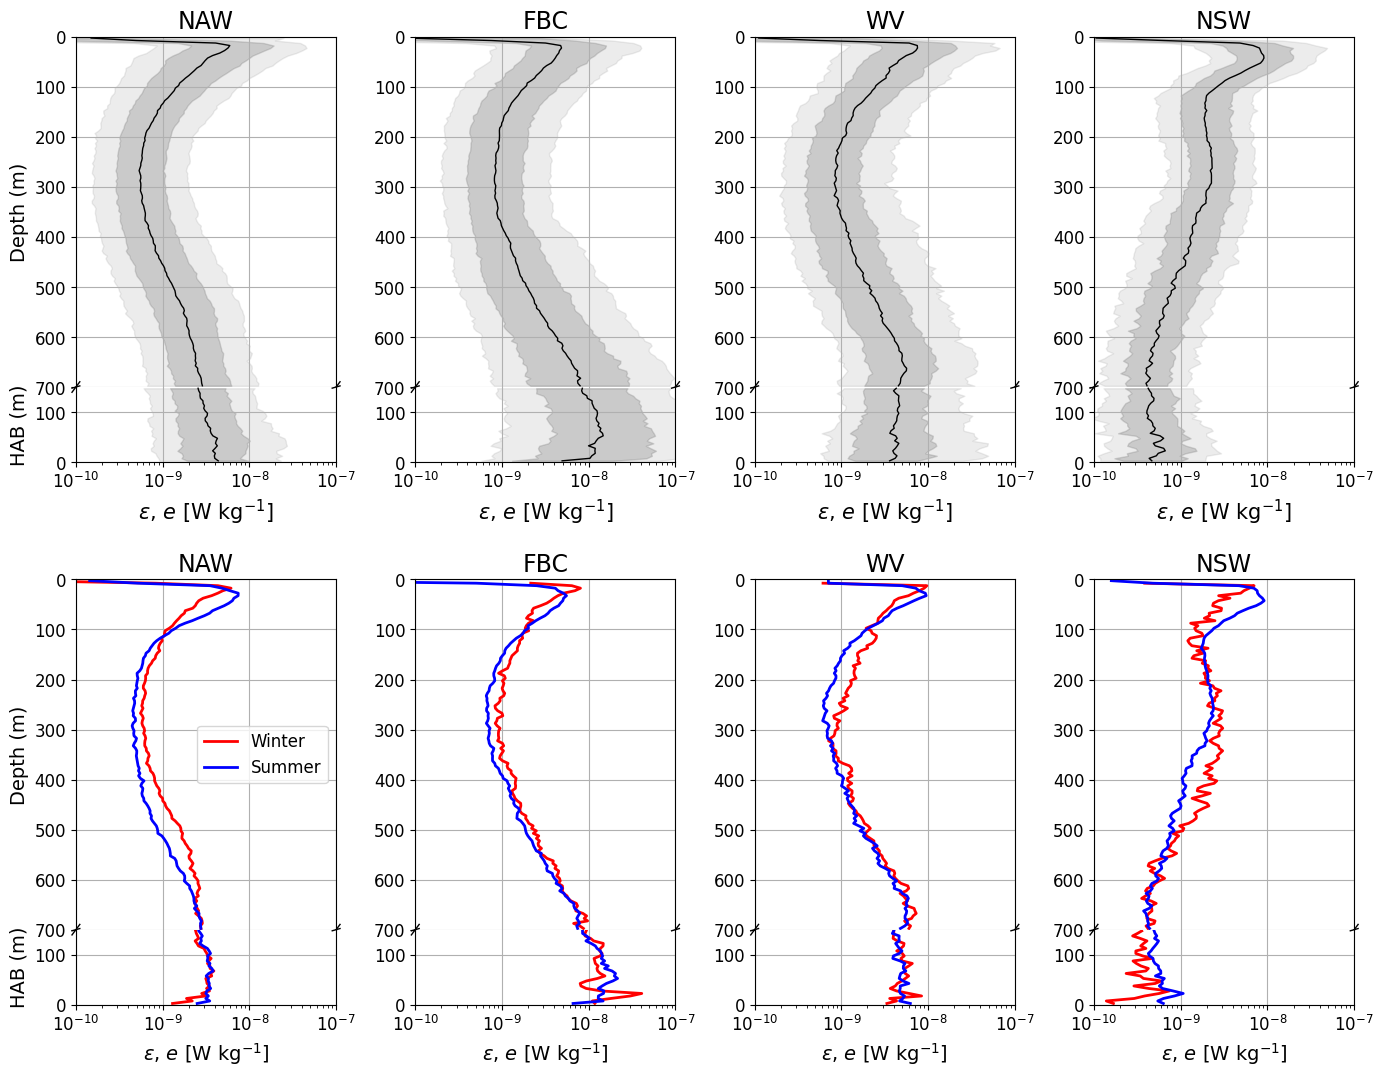

In [225]:
import matplotlib.pyplot as plt
import numpy as np

depth_upper_plot = 700  # Depth limit for upper section

with plt.style.context(plotting_style):
    fig, axs = plt.subplots(2, 4, figsize=(14, 11), sharey=False)
    axs = axs.flatten()

    # lists now contain tuples (stats_df, stats_bottom_df)
    stats_list = [stats_ALW, stats_FBC, stats_WVJ, stats_NSW]
    winter_list = [stats_ALW_winter, stats_FBC_winter, stats_WVJ_winter, stats_NSW_winter]
    summer_list = [stats_ALW_summer, stats_FBC_summer, stats_WVJ_summer, stats_NSW_summer]
    stats_list_bot = [stats_ALW_bot, stats_FBC_bot, stats_WVJ_bot, stats_NSW_bot]
    winter_list_bot = [stats_ALW_winter_bot, stats_FBC_winter_bot, stats_WVJ_winter_bot, stats_NSW_winter_bot]
    summer_list_bot = [stats_ALW_summer_bot, stats_FBC_summer_bot, stats_WVJ_summer_bot, stats_NSW_summer_bot]
    site_names = ["NAW", "FBC", "WV", "NSW"]

    agg = "mean"

    for i, ax in enumerate(axs):
        col = i % 4
        if i < 4:
            # ---------- Top row: main median plots ----------
            stats_df, stats_bottom_df = stats_list[col], stats_list_bot[col]
            ax.set_title(site_names[col], fontsize = 17)

            # Split top & bottom
            top_df = stats_df[stats_df["depth_mid"] <= depth_upper_plot]

            # Create inset for bottom
            ax_top = ax
            ratio = bottom_thickness / depth_upper_plot  # 250 / 750 = 1/3
            # create inset below top axis
            ax_bottom = ax.inset_axes([0, -ratio, 1, ratio], sharex=ax)

            # --- Upper section ---
            ax_top.plot(top_df[agg], top_df["depth_mid"], color="black", label="Log-mean")
            ax_top.fill_betweenx(top_df["depth_mid"], top_df["p25"], top_df["p75"], color="gray", alpha=0.3)
            ax_top.fill_betweenx(top_df["depth_mid"], top_df["p10"], top_df["p90"], color="gray", alpha=0.15)
            ax_top.set_ylim(depth_upper_plot, 0)

            # --- Lower section ---
            # Convert "from bottom" depths back to true depths
            max_depth = stats_df["depth_mid"].max()
            bottom_depth_true = max_depth - stats_bottom_df["depth_mid"]

            ax_bottom.plot(stats_bottom_df[agg], stats_bottom_df["depth_mid"], color="black")
            ax_bottom.fill_betweenx(stats_bottom_df["depth_mid"], stats_bottom_df["p25"], stats_bottom_df["p75"], color="gray", alpha=0.3)
            ax_bottom.fill_betweenx(stats_bottom_df["depth_mid"], stats_bottom_df["p10"], stats_bottom_df["p90"], color="gray", alpha=0.15)
            ax_bottom.set_ylim(0, bottom_thickness)

            # Hide overlapping spines to show the "break"
            ax_bottom.spines['top'].set_visible(False)
            ax_top.spines['bottom'].set_visible(False)
            ax_bottom.xaxis.set_tick_params(labelbottom=True)

            # Diagonal break marks
            d = .015
            kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
            ax_top.plot((-d, +d), (-d, +d), **kwargs)
            ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            kwargs.update(transform=ax_bottom.transAxes)
            ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            # Axis labels & scaling
            ax_bottom.set_xlabel(r"$\epsilon$, $e$ [W kg$^{-1}$]", fontsize = 15)
            if col == 0:
                ax_top.set_ylabel("Depth (m)", fontsize = 14)
                ax_bottom.set_ylabel("HAB (m)", fontsize = 14)

            ax_bottom.set_xscale("log")
            ax_top.set_xscale("log")
            ax_top.set_xlim(1e-10, 1e-7)
            ax_top.grid(True)
            ax_bottom.grid(True)

        else:
            # ---------- Bottom row: winter/summer medians ----------
            stats_winter, stats_winter_bottom = winter_list[col - 4], winter_list_bot[col - 4]
            stats_summer, stats_summer_bottom = summer_list[col - 4], summer_list_bot[col - 4]
            ax.set_title(site_names[col - 4], fontsize = 17)

            # Top section (<= 750 m)
            top_w = stats_winter[stats_winter["depth_mid"] <= depth_upper_plot]
            top_s = stats_summer[stats_summer["depth_mid"] <= depth_upper_plot]
            max_depth = stats_winter["depth_mid"].max()

            ax_top = ax
            ratio = bottom_thickness / depth_upper_plot  # 250 / 750 = 1/3
            # create inset below top axis
            ax_bottom = ax.inset_axes([0, -ratio, 1, ratio], sharex=ax)

            # --- Upper section ---
            ax_top.plot(top_w[agg], top_w["depth_mid"], color="red", lw=2, label="Winter")
            ax_top.plot(top_s[agg], top_s["depth_mid"], color="blue", lw=2, label="Summer")
            ax_top.set_ylim(depth_upper_plot, 0)

            # --- Lower section ---
            ax_bottom.plot(stats_winter_bottom[agg], stats_winter_bottom["depth_mid"], color="red", lw=2)
            ax_bottom.plot(stats_summer_bottom[agg],stats_summer_bottom["depth_mid"], color="blue", lw=2)
            ax_bottom.set_ylim(0, bottom_thickness)

            # Break marks
            d = .015
            ax_top.spines['bottom'].set_visible(False)
            ax_bottom.spines['top'].set_visible(False)
            kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
            ax_top.plot((-d, +d), (-d, +d), **kwargs)
            ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
            kwargs.update(transform=ax_bottom.transAxes)
            ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
            ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

            ax_bottom.set_xlabel(r"$\epsilon$, $e$ [W kg$^{-1}$]", fontsize = 14)
            if col == 0:
                ax_top.set_ylabel("Depth (m)", fontsize = 14)
                ax_bottom.set_ylabel("HAB (m)", fontsize = 14)

            ax_bottom.set_xscale("log")
            ax_top.set_xscale("log")
            ax_top.set_xlim(1e-10, 1e-7)
            ax_top.grid(True)
            ax_bottom.grid(True)

    for ax in axs:
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    axs[4].legend()
    fig.tight_layout()
    fig.savefig(thesis_resources_path + "/Profiles_regions.png", dpi=300, bbox_inches='tight')
    plt.show()


In [5]:
bg_yaml_path = '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/bg_dissipation.yaml'
with open(bg_yaml_path, 'r') as file:
    bg_yaml = yaml.safe_load(file)
#profile_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['profile_range']
#depth_range = bg_yaml['sg'+ Glider][Glider+'/'+Mission]['depth_range']

#print(f'Profile Range: {profile_range}, Depth Range: {depth_range}')

In [121]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import Wedge
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
def get_month_color(month):
    """Return a color from a colormap depending on the month (1–12)."""
    cmap = plt.cm.twilight_shifted
    return cmap((month) / 12.0)  # Normalize month to [0, 1]

# --- Assign each glider an x-position ---
gliders = list(bg_yaml.keys())
x_positions = range(len(gliders))

# --- Collect all c-values for histogram ---
all_cvals = [values['c'] for missions in bg_yaml.values() for values in missions.values()]

bg_months = np.unique(np.array([values.get('bg_month', None) for missions in bg_yaml.values() for values in missions.values()]))

with plt.style.context(plotting_style):
    fig, (ax_scatter, ax_hist) = plt.subplots(
        1, 2, figsize=(14, 4),
        gridspec_kw={'width_ratios': [3, 1]},
        sharey=True
    )

    # --- Scatter plot ---
    for i, (glider, missions) in enumerate(bg_yaml.items()):
        for mission, values in missions.items():
            c_val = values['c']
            month = values.get('bg_month', None)
            color = get_month_color(month) if month is not None else 'gray'

            ax_scatter.scatter(i, c_val, color=color, marker='x', s=60, zorder=5,linewidth=2)
            if mission in ['005/20080606', '005/20090829', '012/20070831', '101/20070609']:
                ax_scatter.text(
                    i, c_val+0.005, mission.split('/')[1],
                    fontsize=11, va='center', color=color, zorder=6,ha='center', fontweight='bold')
            else:
                ax_scatter.text(
                    i, c_val-0.005, mission.split('/')[1],
                    fontsize=11, va='center', color=color, zorder=6,ha='center', fontweight='bold')

    # Axis and labels
    ax_scatter.set_xticks(x_positions)
    ax_scatter.set_xticklabels(gliders, fontsize = 16)
    ax_scatter.set_yticklabels(ax_scatter.get_yticklabels(), fontsize = 16)
    ax_scatter.set_xlabel("Gliders", fontsize=18)
    ax_scatter.set_ylabel(r"$c_{\epsilon}$", fontsize=18)
    #ax_scatter.set_title("Proportionality constant for each glider mission")
    ax_scatter.grid(axis='y', linestyle='--', alpha=0.7)

    # Create inset axes
    ax_inset = inset_axes(
        ax_scatter, width="90%", height="90%", loc="upper left",
        bbox_to_anchor=(-0.55,0.1, 0.7, 0.7),
        bbox_transform=ax_scatter.transAxes, borderpad=0, ### add text
    )
    ax_inset.set_aspect('equal')
    ax_inset.axis('off')
    # Set axes limits to fully fit circle
    ax_inset.set_xlim(-1, 1)
    ax_inset.set_ylim(-1, 1)

    # --- Define months and colormap ---
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    radius = 0.95
    rotation_offset = 90

    # --- Create all wedges first ---
    wedges = []
    for m in range(12):
        if m+1 not in bg_months:
            continue
        theta1 = (rotation_offset + m*30) % 360
        theta2 = (rotation_offset + (m+1)*30) % 360
        w = Wedge((0,0), radius, theta1, theta2, facecolor=get_month_color(m+1), edgecolor='k', lw=0.3)
        wedges.append(w)

        #Label positions slightly outside wedge
        angle = np.deg2rad(rotation_offset + (m + 0.5) * 30)
        r_label = radius * 1.3
        ax_inset.text(
            r_label * np.cos(angle),
            r_label * np.sin(angle),
            month_names[m],
            ha='center', va='center',
            fontsize=15,
            rotation=0,
            rotation_mode='anchor')
    for w in wedges:
        ax_inset.add_patch(w)

    # Optional white center circle for donut look
    ax_inset.add_patch(plt.Circle((0, 0), radius * 0.2, color='white', zorder=11))
    ### set a title of the inset but below the month labels
    ax_inset.text(0, - radius * 2, "Month of Background\nEstimate", ha='center', va='center', fontsize=18)

    # --- Histogram on the right ---
    ax_hist.hist(all_cvals, bins=6, orientation='horizontal', color='gray', alpha=0.7)
    ax_hist.set_xlabel("Counts", fontsize=18)
    ax_hist.set_xticklabels([0,1,2,3,4], fontsize = 16)
    ax_hist.set_title(r"Distribution of $c_{\epsilon}$")
    ax_hist.grid(axis='y', linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.savefig(f"{thesis_resources_path}/Glider_missions_c_values.png", dpi=300, bbox_inches='tight')
plt.show()


NameError: name 'bg_yaml' is not defined

In [51]:
mld_list = []
mld_type = 'mld_CR1'# 
#mld_type = 'mld_CR_Hs40m'
#mld_type = 'mld_threshold'
#mld_type = 'mld_threshold_Hs40m'
binned_list = []
for glider in tqdm(config['gliders'], desc="Processing gliders"):
    for mission in glider['missions']:
        if mission['folder'] == '014/20080214' or mission['folder'] == '104/20080214':
            continue
        folder = mission.get('folder')
        print(folder)
        if folder == 'no folder':
            continue
        
        file_path = f"{destination_folder}/{folder}/{mld_type}.nc"
        mld_ds = xr.open_dataset(file_path)
        binned_ds = xr.open_dataset(f"{destination_folder}/{folder}/dissipation_binned.nc")

        mld_list.append(mld_ds)
        binned_list.append(binned_ds)

Processing gliders:  11%|█         | 1/9 [00:00<00:00,  8.55it/s]

005/20080606
005/20090829
005/20081106
012/20070831
014/20080829
016/20071113


Processing gliders:  44%|████▍     | 4/9 [00:00<00:00, 15.93it/s]

016/20080607
016/20090605
101/20070609
101/20081108
no folder
102/20071113
no folder
103/20070218
103/20071113


Processing gliders: 100%|██████████| 9/9 [00:00<00:00, 18.33it/s]

103/20090223
no folder
no folder
104/20070901
no folder
no folder
no folder
no folder
no folder
no folder


In [23]:
for mld in binned_list:
    print(str(mld.Glider) + " " + str(mld.Mission) + " " + str(mld.c_epsilon))

005 20080606 0.074
005 20090829 0.059
005 20081106 0.115
012 20070831 0.059
014 20080829 0.074
016 20071113 0.122
016 20080607 0.0978
016 20090605 0.075
101 20070609 0.062
101 20081108 0.087
102 20071113 0.08
103 20070218 0.12
103 20071113 0.082
103 20090223 0.11
104 20070901 0.069


In [57]:
mld_list, binned_list = cut_all_to_region(mld_list, binned_list, IFR_msk, 0)

In [56]:
dissipation_all = []
depth_all = []
for binned_ds in tqdm(binned_list):
    profiles = np.unique(binned_ds['PROFILE_NUMBER'].values)
    dissipation_array = np.full(len(profiles), np.nan, dtype=float)
    depth_array = np.full(len(profiles), np.nan, dtype=float)
    for i, p in enumerate(profiles):
        # mask rows corresponding to this profile
        mask = binned_ds['PROFILE_NUMBER'] == p
        # select DISSIPATION_LEM for this profile along TIME and DEPTH
        diss_profile = binned_ds['DISSIPATION_LEM'].where(mask, drop=True)
        depth_profile = binned_ds['DEPTH'].where(mask, drop=True)
        
        # get depth index closest to 50 m *for this profile*
        depth_idx = abs(depth_profile - 50).argmin().item()
        
        #print(f"Profile {p}, Depth index: {depth_idx}, Depth value: {diss_profile.isel(TIME=depth_idx).item()} m")
        # get value at that depth, optionally mean over TIME if multiple samples
        dissipation_array[i] = diss_profile[depth_idx]
        depth_array[i] = depth_profile[depth_idx]
    depth_all.append(depth_array)
    dissipation_all.append(dissipation_array)

  0%|          | 0/15 [00:00<?, ?it/s]

 13%|█▎        | 2/15 [00:23<02:33, 11.80s/it]


KeyboardInterrupt: 

In [36]:
len(dissipation_all)

15

In [46]:
dissipation_array_all = np.concatenate(dissipation_all)

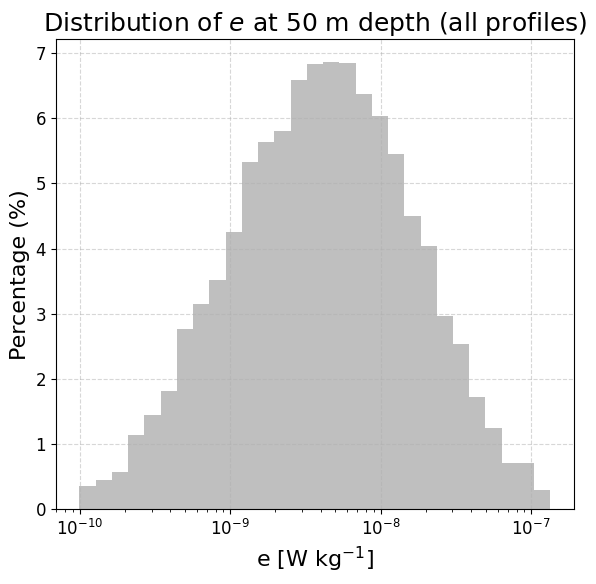

In [56]:
### plot a logarithmic histogram of dissipation_array_all
dissipation_50m = dissipation_array_all[np.isfinite(dissipation_array_all)]
### cut out values below and above the 1st and 99th percentile
dissipation_50m = dissipation_50m[(dissipation_50m >= np.percentile(dissipation_50m, 0.5)) & (dissipation_50m <= np.percentile(dissipation_50m, 99.5))]
with plt.style.context(plotting_style):
    fig, ax = plt.subplots(figsize=(6,6))
    bins = np.logspace(np.log10(dissipation_50m.min()), np.log10(dissipation_50m.max()), 30)
    ax.hist(dissipation_50m, bins=bins, color='gray', alpha=0.5, density = False, weights=np.ones_like(dissipation_50m) / len(dissipation_50m) * 100)
    ax.set_xscale('log')
    ax.set_xlabel(r'e [W kg$^{-1}$]', fontsize=16)
    ax.set_ylabel('Percentage (%)', fontsize=16)
    ax.set_title('Distribution of $e$ at 50 m depth (all profiles)', fontsize=18)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{thesis_resources_path}/Dissipation_histogram_IFR_50m.png", dpi=300, bbox_inches='tight')
    plt.show()

In [104]:
for mld in mld_list:
    ### add depth range between MLD and H_s
    mld['DR'] =  mld['MLD'] - mld['H_S']

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_DR_cycle(mld_list, n_bins=3, percentile_interval=[10, 90], plotting_style=None):

    # --- Concatenate all datasets efficiently ---
    all_time, all_mld, all_hs = [], [], []

    for mld_ds in mld_list:
        if 'MLD' not in mld_ds:
            continue
        all_time.append(mld_ds['TIME'].values)
        all_mld.append(mld_ds['MLD'].values)
        all_hs.append(mld_ds['H_S'].values)

    # Combine all missions into single arrays
    time = pd.to_datetime(np.concatenate(all_time))
    mld = np.concatenate(all_mld)
    h_s = np.concatenate(all_hs)

    # --- Create DataFrame ---
    df = pd.DataFrame({'time': time, 'MLD': mld, 'H_S': h_s})
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['days_in_month'] = df['time'].dt.days_in_month

    # Fractional month (0–12)
    df['month_frac'] = df['month'] - 1 + df['day'] / df['days_in_month']

    # --- Shift to July–June cycle ---
    df['month_frac'] = (df['month_frac'] - 6) % 12

    # --- Filter H_S above percentile ---
    h_s_95 = np.nanpercentile(df['H_S'], 95)
    df.loc[df['H_S'] > h_s_95, 'H_S'] = np.nan

    # --- Compute DR and filter DR > 0 ---
    df['DR'] = df['MLD'] - df['H_S']
    df = df[df['DR'] > 0]

    # --- Bin data ---
    bins = np.linspace(0, 12, 12 * n_bins + 1)
    df['bin'] = np.digitize(df['month_frac'], bins) - 1

    # --- Compute DR statistics per bin ---
    grouped = df.groupby('bin').agg(
        DR_mean=('DR', 'mean'),
        DR_p10=('DR', lambda x: np.nanpercentile(x, percentile_interval[0])),
        DR_p90=('DR', lambda x: np.nanpercentile(x, percentile_interval[1])),
        N_profiles=('DR', 'count')
    ).reset_index()

    # --- Compute bin centers ---
    bin_centers = (bins[grouped['bin']] + bins[grouped['bin'] + 1]) / 2

    # --- Plot ---
    with plt.style.context(plotting_style):
        fig, ax1 = plt.subplots(figsize=(12, 6))

        # DR mean + percentiles
        ax1.plot(bin_centers, grouped['DR_mean'], lw=2, color='purple', label='DR mean')
        ax1.fill_between(bin_centers,
                         grouped['DR_p10'], grouped['DR_p90'],
                         color='purple', alpha=0.2, label='10–90 % interval')

        ax1.set_ylabel('DR = MLD − H_s (m)', fontsize=15)
        ax1.invert_yaxis()  # optional
        ax1.grid(alpha=0.3)

        # Bar plot of number of profiles
        ax2 = ax1.twinx()
        ax2.bar(bin_centers, grouped['N_profiles'],
                width=12/(n_bins*20), alpha=0.3, color='grey',
                label='Number of profiles')
        ax2.set_ylabel('Profiles (DR > 0)', fontsize=15)

        # X-axis labels (July–June)
        month_labels = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']
        ax1.set_xlim(0, 12)
        ax1.set_xticks(np.arange(0.5, 12.5))
        ax1.set_xticklabels(month_labels)

        ax1.set_xlabel('Month', fontsize=15)
        ax1.set_title('Yearly Cycle of DR = MLD − H_s (only DR > 0)', fontsize=16)

        # Combined legend
        fig.legend(loc='lower left', bbox_to_anchor=(0.08, 0.15), fontsize=12)
        plt.tight_layout()
        plt.show()


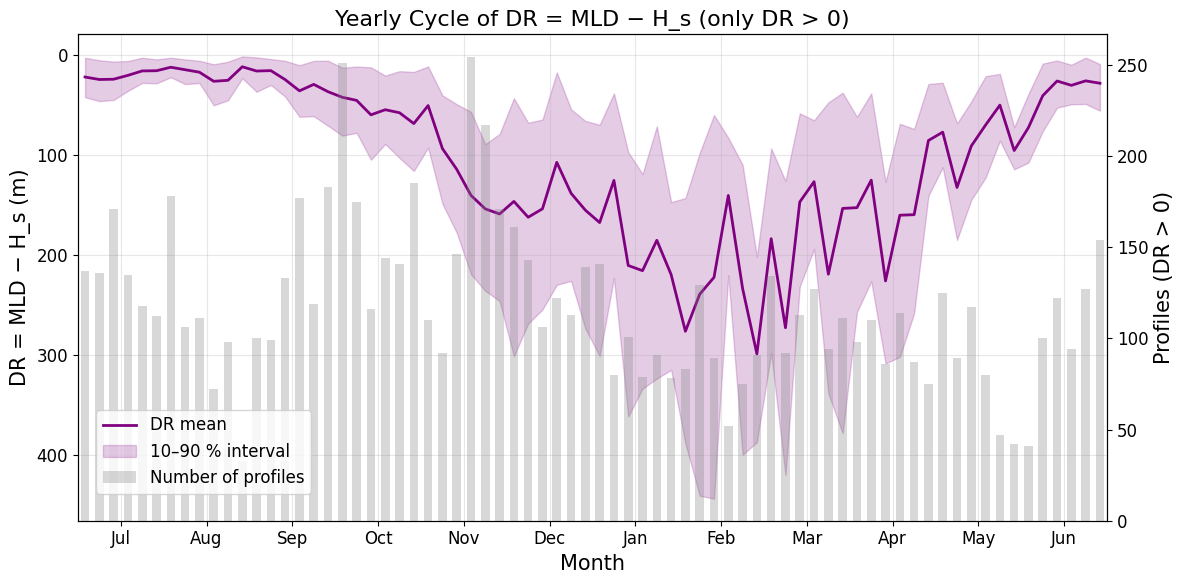

In [112]:
plot_DR_cycle(mld_list, n_bins=6, percentile_interval=[10, 90], plotting_style=plotting_style)

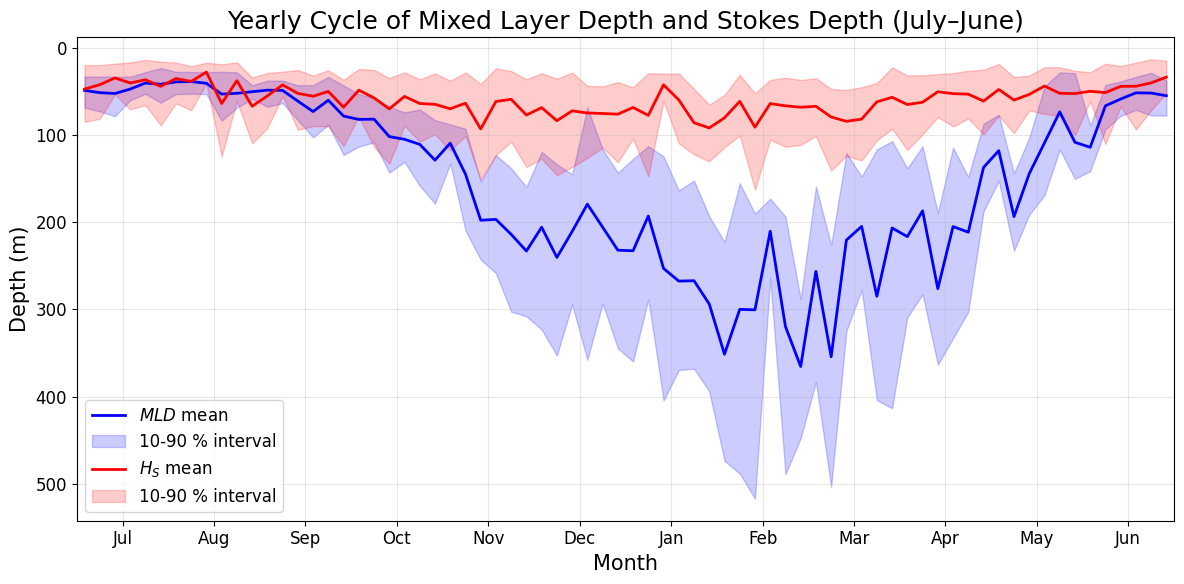

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
n_bins = 6  # bins per month
percentile_interval = [10, 90]  # 10th and 90th percentile

# --- Concatenate all datasets efficiently ---
all_time, all_mld, all_hs = [], [], []

for mld_ds in mld_list:
    if 'MLD' not in mld_ds:
        continue
    all_time.append(mld_ds['TIME'].values)
    all_mld.append(mld_ds['MLD'].values)
    all_hs.append(mld_ds['H_S'].values)

# Combine all missions into single arrays
time = pd.to_datetime(np.concatenate(all_time))
mld = np.concatenate(all_mld)
h_s = np.concatenate(all_hs)

# --- Create DataFrame ---
df = pd.DataFrame({'time': time, 'MLD': mld, 'H_S': h_s})
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['days_in_month'] = df['time'].dt.days_in_month

# Fractional month for continuous binning
df['month_frac'] = df['month'] - 1 + df['day'] / df['days_in_month']  # 0–12

# --- Shift to July–June cycle ---
df['month_frac'] = (df['month_frac'] - 6) % 12  # July=0, June=11+

# --- Filter H_S below 99th percentile ---
h_s_99 = np.nanpercentile(df['H_S'], 95)
df.loc[df['H_S'] > h_s_99, 'H_S'] = np.nan  # set extreme values to NaN

# --- Bin data ---
bins = np.linspace(0, 12, 12 * n_bins + 1)
df['bin'] = np.digitize(df['month_frac'], bins) - 1

# --- Compute mean and percentiles ---
grouped = df.groupby('bin').agg({
    'MLD': ['mean', lambda x: np.nanpercentile(x, percentile_interval[0]), lambda x: np.nanpercentile(x, percentile_interval[1])],
    'H_S': ['mean', lambda x: np.nanpercentile(x, percentile_interval[0]), lambda x: np.nanpercentile(x, percentile_interval[1])]
})

grouped.columns = ['MLD_mean', 'MLD_p25', 'MLD_p75', 'H_S_mean', 'H_S_p25', 'H_S_p75']
grouped = grouped.reset_index()

# --- Correct bin_centers for only non-empty bins ---
bin_centers = (bins[grouped['bin']] + bins[grouped['bin'] + 1]) / 2

# --- Plot ---
with plt.style.context(plotting_style):
    fig, ax = plt.subplots(figsize=(12, 6))

    # MLD
    ax.plot(bin_centers, grouped['MLD_mean'], color='blue', lw=2, label=r'$MLD$ mean')
    ax.fill_between(bin_centers,
                    grouped['MLD_p25'], grouped['MLD_p75'],
                    color='blue', alpha=0.2, label=r'10-90 % interval')

    # H_S
    ax.plot(bin_centers, grouped['H_S_mean'], color='red', lw=2, label=r'$H_S$ mean')
    ax.fill_between(bin_centers,
                    grouped['H_S_p25'], grouped['H_S_p75'],
                    color='red', alpha=0.2, label=r'10-90 % interval')

    # X-axis and labels (July–June)
    ax.set_xlim(0, 12)
    month_labels = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']
    ax.set_xticks(np.arange(0.5, 12.5))
    ax.set_xticklabels(month_labels)

    ax.set_xlabel('Month', fontsize=15)
    ax.set_ylabel('Depth (m)', fontsize=15)
    ax.set_title('Yearly Cycle of Mixed Layer Depth and Stokes Depth (July–June)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.invert_yaxis()  # if desired for MLD
    plt.tight_layout()
    #fig.savefig(thesis_resources_path + "/MLD_Hs_yearly_cycle.png", dpi=300, bbox_inches='tight')
    plt.show()


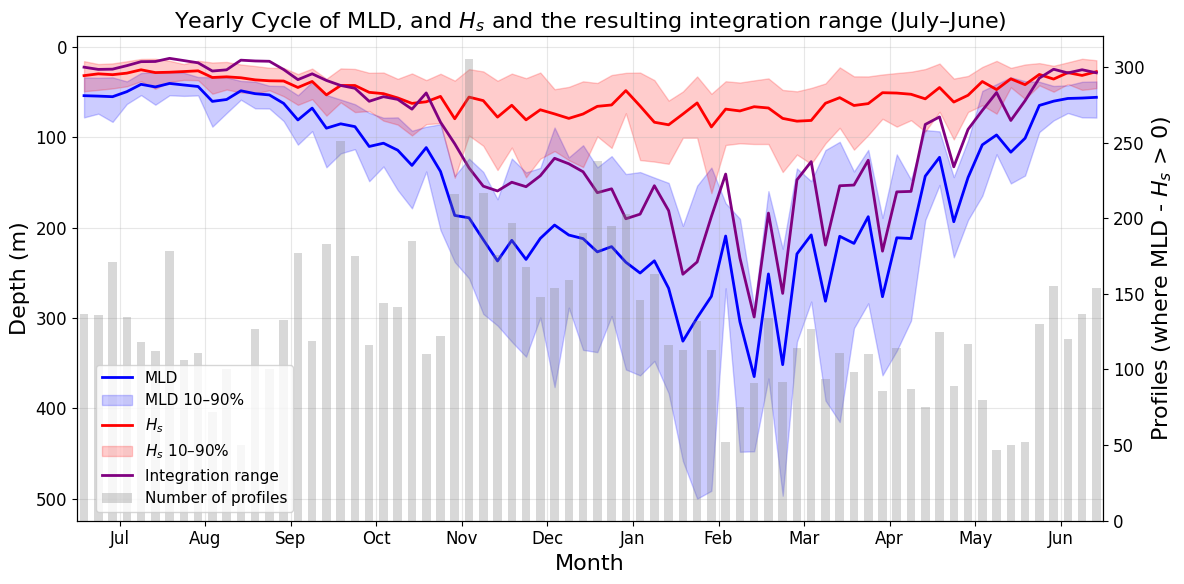

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameters ---
n_bins = 6
percentile_interval = [10, 90]

# --- Concatenate all datasets efficiently ---
all_time, all_mld, all_hs = [], [], []

for mld_ds in mld_list:
    if 'MLD' not in mld_ds:
        continue
    all_time.append(mld_ds['TIME'].values)
    all_mld.append(mld_ds['MLD'].values)
    all_hs.append(mld_ds['H_S'].values)

time = pd.to_datetime(np.concatenate(all_time))
mld = np.concatenate(all_mld)
h_s = np.concatenate(all_hs)

# --- Create DataFrame ---
df = pd.DataFrame({'time': time, 'MLD': mld, 'H_S': h_s})
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['days_in_month'] = df['time'].dt.days_in_month

# Fractional month (0–12)
df['month_frac'] = df['month'] - 1 + df['day'] / df['days_in_month']
df['month_frac'] = (df['month_frac'] - 6) % 12  # July–June cycle

# --- Filter extreme H_S ---
h_s_95 = np.nanpercentile(df['H_S'], 95)
df.loc[df['H_S'] > h_s_95, 'H_S'] = np.nan

# --- Compute DR ---
df['DR'] = df['MLD'] - df['H_S']
df = df[df['DR'] > 0]

# --- Bin data ---
bins = np.linspace(0, 12, 12 * n_bins + 1)
df['bin'] = np.digitize(df['month_frac'], bins) - 1
bin_centers = (bins[grouped['bin']] + bins[grouped['bin'] + 1]) / 2

# --- Compute statistics ---
grouped = df.groupby('bin').agg(
    DR_mean=('DR', 'mean'),
    DR_p10=('DR', lambda x: np.nanpercentile(x, percentile_interval[0])),
    DR_p90=('DR', lambda x: np.nanpercentile(x, percentile_interval[1])),
    MLD_mean=('MLD', 'mean'),
    MLD_p10=('MLD', lambda x: np.nanpercentile(x, percentile_interval[0])),
    MLD_p90=('MLD', lambda x: np.nanpercentile(x, percentile_interval[1])),
    H_S_mean=('H_S', 'mean'),
    H_S_p10=('H_S', lambda x: np.nanpercentile(x, percentile_interval[0])),
    H_S_p90=('H_S', lambda x: np.nanpercentile(x, percentile_interval[1])),
    N_profiles=('DR', 'count')
).reset_index()

# --- Plot ---
with plt.style.context(plotting_style):
    fig, ax = plt.subplots(figsize=(12, 6))

    # MLD
    ax.plot(bin_centers, grouped['MLD_mean'], color='blue', lw=2, label='MLD')
    ax.fill_between(bin_centers, grouped['MLD_p10'], grouped['MLD_p90'],
                    color='blue', alpha=0.2, label='MLD 10–90%')

    # H_S
    ax.plot(bin_centers, grouped['H_S_mean'], color='red', lw=2, label=r'$H_s$')
    ax.fill_between(bin_centers, grouped['H_S_p10'], grouped['H_S_p90'],
                    color='red', alpha=0.2, label=r'$H_s$ 10–90%')
    
    # DR
    ax.plot(bin_centers, grouped['DR_mean'], color='purple', lw=2, label='Integration range')
    #ax.fill_between(bin_centers, grouped['DR_p10'], grouped['DR_p90'],
    #                color='purple', alpha=0.2, label='DR 10–90%')

    # X-axis (July–June)
    month_labels = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']
    ax.set_xlim(0, 12)
    ax.set_xticks(np.arange(0.5, 12.5))
    ax.set_xticklabels(month_labels)
    ax.set_xlabel('Month', fontsize=16)

    # Y-axis (Depth)
    ax.set_ylabel('Depth (m)', fontsize=16)
    ax.invert_yaxis()  # so depth increases downward
    ax.grid(alpha=0.3)

    # Secondary axis: number of profiles as bars
    ax2 = ax.twinx()
    ax2.bar(bin_centers, grouped['N_profiles'], width=12/(n_bins*20),
            color='grey', alpha=0.3, label='Number of profiles')
    ax2.set_ylabel(r'Profiles (where MLD - $H_s$ > 0)', fontsize=16)

    # Legend
    lines, labels = [], []
    for a in [ax, ax2]:
        l, lab = a.get_legend_handles_labels()
        lines += l
        labels += lab
    fig.legend(lines, labels, loc='lower left', bbox_to_anchor=(0.08, 0.12), fontsize=11)

    plt.title(r'Yearly Cycle of MLD, and $H_s$ and the resulting integration range (July–June)', fontsize=16)
    plt.tight_layout()
    plt.savefig(thesis_resources_path + "/MLD_Hs_DR_yearly_cycle.png", dpi=300, bbox_inches='tight')
    plt.show()


In [58]:
### add epsilon sum and also change all epsilon_q to nan if negative
for mld_ds in mld_list:
    mld_ds['EPSILON_Q'] = mld_ds['EPSILON_Q'].where(mld_ds['EPSILON_Q'] > 0, np.nan)
    mld_ds['EPS_SUM'] = mld_ds['EPSILON_TAU'] + mld_ds['EPSILON_Q']

In [77]:
def plot_dissipation_time_series(mld_ds_list, n_bins=3, percentile_interval=[10, 90], title=None):
    """
    Plot time series of dissipation variables from a list of MLD datasets.
    Produces two subplots:
      (1) Upper: wind (EPSILON_TAU) and buoyancy (EPSILON_Q) dissipation with percentile shading.
      (2) Lower: LEM dissipation (DISSIPATION_LEM_TOTAL) and the total sum (EPSILON_SUM) with percentile shading.

    Parameters
    ----------
    mld_ds_list : list of xarray.Dataset
        List of MLD datasets containing:
        'DISSIPATION_LEM_TOTAL', 'EPSILON_TAU', 'EPSILON_Q', 'EPSILON_SUM'.
    n_bins : int
        Number of bins per month.
    percentile_interval : list of two floats
        Percentiles to shade (e.g., [10, 90]).
    title : str or None
        Plot title.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes array
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    vars_to_plot = ['DISSIPATION_LEM_TOTAL', 'EPSILON_TAU', 'EPSILON_Q', 'EPS_SUM']

    # --- Concatenate all datasets ---
    all_time, all_data = [], {v: [] for v in vars_to_plot}

    for ds in mld_ds_list:
        all_time.append(ds['TIME'].values)
        for v in vars_to_plot:
            if v in ds:
                all_data[v].append(ds[v].values)
            else:
                all_data[v].append(np.full_like(ds['TIME'].values, np.nan))

    time = pd.to_datetime(np.concatenate(all_time))
    combined_data = {v: np.concatenate(all_data[v]) for v in vars_to_plot}

    # --- Build DataFrame ---
    df = pd.DataFrame({'time': time, **combined_data})
    df = df.sort_values('time')

    # --- Create time bins ---
    start_month = df['time'].min().to_period('M').to_timestamp()
    end_month = df['time'].max().to_period('M').to_timestamp() + pd.offsets.MonthEnd(0)
    bin_edges = pd.date_range(start=start_month, end=end_month + pd.offsets.MonthEnd(1),
                              freq=pd.DateOffset(days=int(30 / n_bins)))

    # Assign bins
    time_numeric = df['time'].values.astype('int64')
    bin_edges_numeric = bin_edges.values.astype('int64')
    df['bin'] = np.digitize(time_numeric, bin_edges_numeric) - 1

    # --- Aggregate statistics ---
    agg_dict = {}
    for v in vars_to_plot:
        agg_dict[v] = [
            ('median', 'median'),
            (f"{percentile_interval[0]}", lambda x, p=percentile_interval[0]: np.nanpercentile(x, p)),
            (f"{percentile_interval[1]}", lambda x, p=percentile_interval[1]: np.nanpercentile(x, p))
        ]

    grouped = df.groupby('bin').agg(agg_dict)
    grouped.columns = [f"{v}_{stat}" for v, stat in grouped.columns]
    grouped = grouped.reset_index()

    all_bins = np.arange(len(bin_edges) - 1)
    grouped = grouped.set_index('bin').reindex(all_bins).reset_index()
    bin_centers = [bin_edges[i] + (bin_edges[i + 1] - bin_edges[i]) / 2 for i in all_bins]

    # --- Plot ---
    with plt.style.context(plotting_style):
        fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
        colors = {
            'EPSILON_TAU': 'blue',
            'EPSILON_Q': 'red',
            'DISSIPATION_LEM_TOTAL': 'black',
            'EPS_SUM': 'green'
        }
        labels = {
            'EPSILON_TAU': r'$E_{\tau}$',
            'EPSILON_Q': r'$E_{Q}$',
            'DISSIPATION_LEM_TOTAL': r'$E_{obs}$',
            'EPS_SUM': r'$E_{\tau} + E_{Q}$'
        }

        # --- Upper panel: wind + buoyancy ---
        for v in ['EPSILON_TAU', 'EPSILON_Q']:
            ax[0].plot(bin_centers, grouped[f"{v}_median"], color=colors[v], lw=2, label=labels[v])
            ax[0].fill_between(bin_centers,
                            grouped[f"{v}_{percentile_interval[0]}"],
                            grouped[f"{v}_{percentile_interval[1]}"],
                            color=colors[v], alpha=0.2)

        # --- Lower panel: LEM + total sum ---
        for v in ['DISSIPATION_LEM_TOTAL', 'EPS_SUM']:
            ax[1].plot(bin_centers, grouped[f"{v}_median"], color=colors[v], lw=2, label=labels[v])
            ax[1].fill_between(bin_centers,
                            grouped[f"{v}_{percentile_interval[0]}"],
                            grouped[f"{v}_{percentile_interval[1]}"],
                            color=colors[v], alpha=0.2)

        ax[0].set_title(r"Integrated Dissipation of Wind ($E_{\tau}$) and Buoyancy ($E_{Q}$)")
        ax[1].set_title(r"Integrated Dissipation observed ($E_{obs}$) and calculated ($E_{\tau}$ + $E_{Q}$)")

        #[ax.set_xlabel('Time') for ax in ax]
        [ax.set_xlim(bin_edges[0], bin_edges[-4]) for ax in ax]
        [ax.set_ylabel('Dissipation [W kg$^{-1}$ m]', fontsize = 15) for ax in ax]
        [ax.set_yscale('log') for ax in ax]
        [ax.set_ylim(1e-8, 2e-4) for ax in ax]
        [ax.grid(True, alpha=0.3) for ax in ax]
        [ax.legend(loc = "lower left") for ax in ax]

        if title:
            fig.suptitle(title, fontsize=14)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig, ax


/Users/tillmoritz/miniconda3/envs/dissipationSML/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1437: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


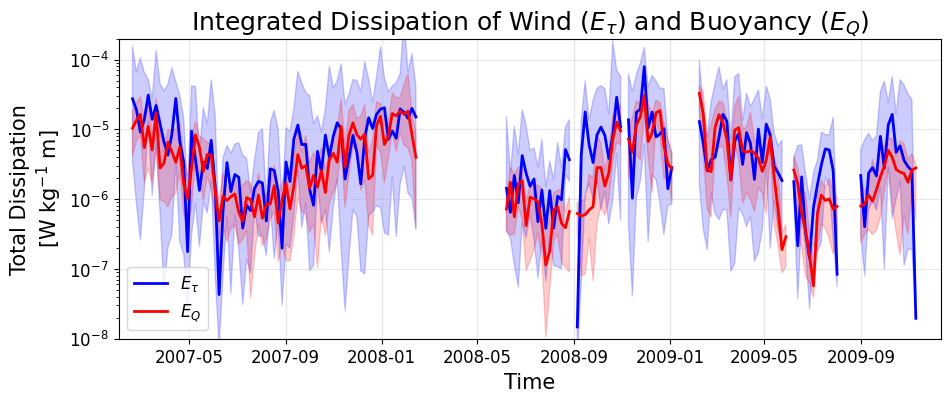

In [84]:
fig, ax = plot_dissipation_time_series(mld_list, n_bins=6, percentile_interval=[10,90])
#fig.savefig(thesis_resources_path + "/Dissipation_time_series.png", dpi=300, bbox_inches='tight')
### delete ax[1] from the figure but take its x-axis limits and labels and put them on ax[0]
fig.canvas.draw()

# Copy x-axis from ax[1] to ax[0]
ax[0].set_xlabel('Time', fontsize=15)
ax[0].set_ylabel('Total Dissipation\n'+r'[W kg$^{-1}$ m]', fontsize=15)
fig.delaxes(ax[1])
fig.set_size_inches(9, 8)
fig.savefig("/Users/tillmoritz/Desktop/OSM/Dissipation_time_series.png", dpi=300, bbox_inches='tight')
plt.show()

In [76]:
xticklabels

['2007-05',
 '2007-09',
 '2008-01',
 '2008-05',
 '2008-09',
 '2009-01',
 '2009-05',
 '2009-09']

In [118]:
import numpy as np
import pandas as pd
import itertools

def bin_monthly_data(ds_list, x_var, y_var, bins_per_month=10, percentile_interval=(25, 75)):
    """
    Bin x/y data per month across one or multiple Datasets, compute median and percentile range per bin.

    Parameters
    ----------
    ds_list : xarray.Dataset or list of xarray.Dataset
        One or more Datasets containing TIME, x_var, y_var.
    x_var, y_var : str
        Variable names for x and y axes.
    bins_per_month : int, optional
        Number of equal-count bins per month (default 10).
    percentile_interval : tuple(int, int), optional
        Percentile interval for spread (default (25, 75)).

    Returns
    -------
    pd.DataFrame with columns:
        ['month', 'x_median', 'y_median', 'x_p_lo', 'x_p_hi', 'y_p_lo', 'y_p_hi']
    """

    # Ensure iterable input
    if not isinstance(ds_list, (list, tuple)):
        ds_list = [ds_list]

    # Extract (month, x, y) data from all datasets efficiently
    month_x_y_iter = itertools.chain.from_iterable(
        zip(ds.TIME.dt.month.values, ds[x_var].values, ds[y_var].values) for ds in ds_list
    )

    # Collect into arrays (filter out NaNs early)
    months, x_vals, y_vals = [], [], []
    for m, x, y in month_x_y_iter:
        if np.isfinite(x) and np.isfinite(y):
            months.append(m)
            x_vals.append(x)
            y_vals.append(y)

    months = np.array(months)
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)

    records = []
    p_lo, p_hi = percentile_interval

    for m in np.unique(months):
        sel = months == m
        if sel.sum() < bins_per_month:
            continue

        x_m = x_vals[sel]
        y_m = y_vals[sel]

        # Sort by x
        sort_idx = np.argsort(x_m)
        x_m = x_m[sort_idx]
        y_m = y_m[sort_idx]

        # Divide into equal-count bins
        bins = np.array_split(np.arange(len(x_m)), bins_per_month)

        for b in bins:
            if len(b) < 3:
                continue
            x_bin = x_m[b]
            y_bin = y_m[b]

            records.append({
                "month": int(m),
                "x_median": np.nanmedian(x_bin),
                "y_median": np.nanmedian(y_bin),
                "x_p_lo": np.nanpercentile(x_bin, p_lo),
                "x_p_hi": np.nanpercentile(x_bin, p_hi),
                "y_p_lo": np.nanpercentile(y_bin, p_lo),
                "y_p_hi": np.nanpercentile(y_bin, p_hi),
            })

    return pd.DataFrame(records)




import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plotting_style = "/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.mplstyle"

def plot_dissipation_summary(df_tau, df_q, df_sum):
    """
    Plot pre-binned dissipation data with IQR lines and median points.

    Parameters
    ----------
    df_tau, df_q, df_sum : pd.DataFrame
        Output of bin_monthly_data() for each pair of variables
    percentile_interval : tuple(int, int)
        Percentile interval plotted as crosshairs
    """
    cmap = plt.cm.twilight_shifted
    boundaries = np.arange(1, 14)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    plot_range = [3e-8, 2e-4]

    with plt.style.context(plotting_style):
        fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

        def draw_binned(ax, df):
            for _, row in df.iterrows():
                m = int(row['month'])
                color = cmap(norm(m))
                ax.plot([row.x_p_lo, row.x_p_hi], [row.y_median, row.y_median], color=color, linewidth=1)
                ax.plot([row.x_median, row.x_median], [row.y_p_lo, row.y_p_hi], color=color, linewidth=1)
                ax.scatter(row.x_median, row.y_median, color=color, s=25, edgecolor='k', linewidth=0.3)

        draw_binned(axs[0], df_tau)
        draw_binned(axs[1], df_q)
        draw_binned(axs[2], df_sum)

        for ax in axs:
            ax.plot(plot_range, plot_range, 'k--', linewidth=0.5)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlim(plot_range)
            ax.set_ylim(plot_range)
            from matplotlib.ticker import LogLocator
            ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
            ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
            ax.grid(which='major', linestyle=':', linewidth=0.5)
            ax.grid(which='minor', visible=False)

        axs[0].set_xlabel(r"ε$_τ$ [W/kg]", fontsize=15)
        axs[1].set_xlabel(r"ε$_Q$ [W/kg]", fontsize=15)
        axs[2].set_xlabel(r"ε$_τ$ + ε$_Q$ [W/kg]", fontsize=15)
        axs[0].set_ylabel("Observed Dissipation [W/kg]", fontsize=15)
        fig.tight_layout(rect=[0, 0, 1.05, 1])

        # --------- Create month cycle --------------
        ax_inset = inset_axes(
            axs[2], width="60%", height="60%", loc="upper left",
            bbox_to_anchor=(1.05,0, 0.7, 0.7),
            bbox_transform=ax_scatter.transAxes, borderpad=0, ### add text
        )
        ax_inset.set_aspect('equal')
        ax_inset.axis('off')
        # Set axes limits to fully fit circle
        ax_inset.set_xlim(-1, 1)
        ax_inset.set_ylim(-1, 1)

        # --- Define months and colormap ---
        month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
        radius = 0.95
        rotation_offset = 90

        # --- Create all wedges first ---
        wedges = []
        for m in range(12):
            theta1 = (rotation_offset + m*30) % 360
            theta2 = (rotation_offset + (m+1)*30) % 360
            w = Wedge((0,0), radius, theta1, theta2, facecolor=get_month_color(m+1), edgecolor='k', lw=0.3)
            wedges.append(w)

            #Label positions slightly outside wedge
            angle = np.deg2rad(rotation_offset + (m + 0.5) * 30)
            r_label = radius * 1.3
            ax_inset.text(
                r_label * np.cos(angle),
                r_label * np.sin(angle),
                month_names[m],
                ha='center', va='center',
                fontsize=10,
                rotation=0,
                rotation_mode='anchor')
        for w in wedges:
            ax_inset.add_patch(w)

        # Optional white center circle for donut look
        ax_inset.add_patch(plt.Circle((0, 0), radius * 0.2, color='white', zorder=11))
        ### set a title of the inset but below the month labels
        ax_inset.text(0, - radius * 1.8, "Month", ha='center', va='center', fontsize=15)
        # ---------------- Colorbar ----------------
        #sc = axs[-1].scatter([], [], c=[], cmap=cmap, norm=norm)  # dummy
        #fig.tight_layout(rect=[0, 0, 1.05, 1])

        # Add colorbar
        #cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
        #cbar = fig.colorbar(sc, ax=axs, orientation='vertical', fraction=0.1, pad=0.05)
        #cbar.set_ticks(np.arange(1.5, 13.5, 1))
        #cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        #                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        #cbar.set_label("Month", fontsize=12)

        #fig.suptitle(f"Dissipation comparison")
    fig.tight_layout()
    return fig, axs



In [119]:
percentile_interval = (25, 75)
bins_per_month = 6
df_tau = bin_monthly_data(mld_list, 'EPSILON_TAU', 'DISSIPATION_LEM_TOTAL', bins_per_month=bins_per_month, percentile_interval=percentile_interval)
df_q   = bin_monthly_data(mld_list, 'EPSILON_Q', 'DISSIPATION_LEM_TOTAL', bins_per_month=bins_per_month, percentile_interval=percentile_interval)
df_sum = bin_monthly_data(mld_list, 'EPS_SUM', 'DISSIPATION_LEM_TOTAL', bins_per_month=bins_per_month, percentile_interval=percentile_interval)

/var/folders/_j/gtdz594n13z3y8k5ml71sv3r0000gn/T/ipykernel_26616/298135033.py:44: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0,0,1,1])


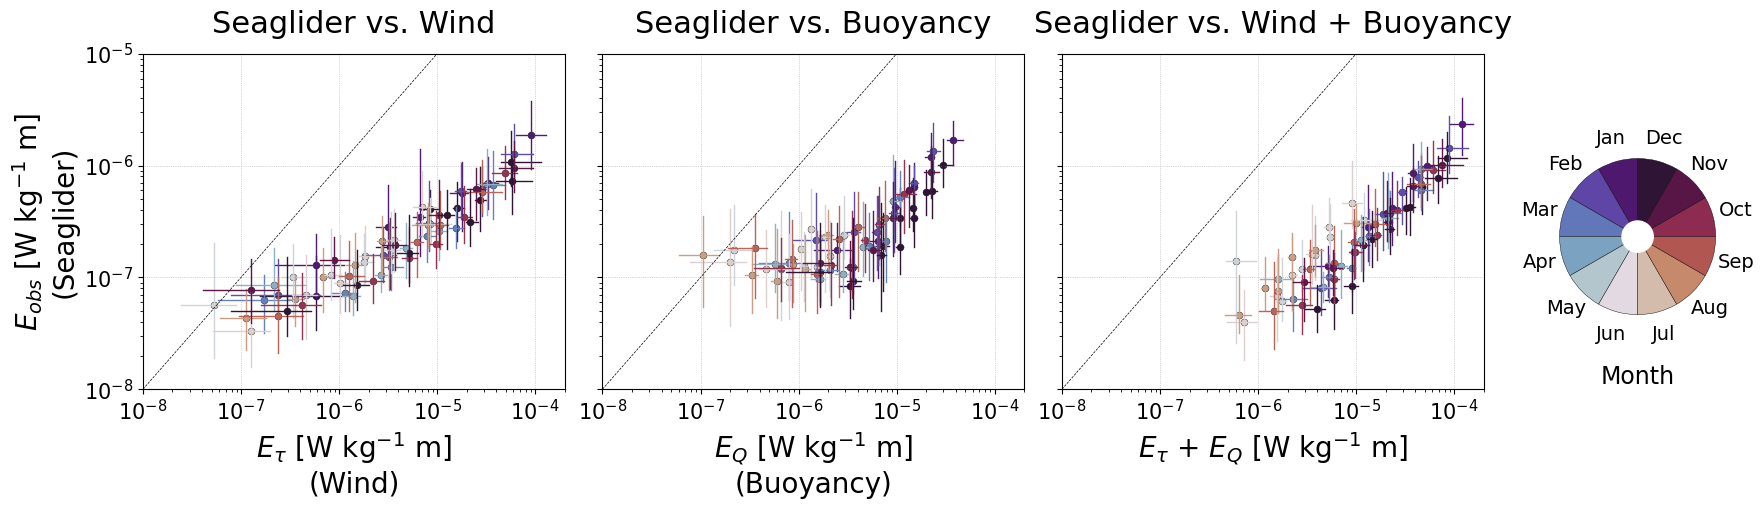

In [147]:
#fig, ax = plot_dissipation_summary(df_tau, df_q, df_sum)
cmap = plt.cm.twilight_shifted
boundaries = np.arange(1, 14)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)
range_x = [1e-8, 2e-4]
range_y = [1e-8, 1e-5]

with plt.style.context(plotting_style):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True, constrained_layout=True)

    def draw_binned(ax, df):
        for _, row in df.iterrows():
            m = int(row['month'])
            color = cmap(norm(m))
            ax.plot([row.x_p_lo, row.x_p_hi], [row.y_median, row.y_median], color=color, linewidth=1)
            ax.plot([row.x_median, row.x_median], [row.y_p_lo, row.y_p_hi], color=color, linewidth=1)
            ax.scatter(row.x_median, row.y_median, color=color, s=25, edgecolor='k', linewidth=0.3)

    draw_binned(axs[0], df_tau)
    draw_binned(axs[1], df_q)
    draw_binned(axs[2], df_sum)

    for ax in axs:
        ax.plot(range_x, range_x, 'k--', linewidth=0.5)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(range_x)
        ax.set_ylim(range_y)
        from matplotlib.ticker import LogLocator
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
        ax.grid(which='major', linestyle=':', linewidth=0.5)
        ax.grid(which='minor', visible=False)

    axs[0].set_xlabel(r"$E_τ$ [W kg$^{-1}$ m]", fontsize=20)
    axs[1].set_xlabel(r"$E_Q$ [W kg$^{-1}$ m]", fontsize=20)
    #axs[1].set_title("Observed vs. Surface forced Dissipation ", fontsize=20)
    axs[2].set_xlabel(r"$E_τ$ + $E_Q$ [W kg$^{-1}$ m]", fontsize=20)
    axs[0].set_ylabel(r"$E_{obs}$ [W kg$^{-1}$ m]"+"\n(Seaglider)", fontsize=20)

    axs[0].set_title("Seaglider vs. Wind", fontsize=22, pad = 15)
    axs[1].set_title("Seaglider vs. Buoyancy", fontsize=22, pad = 15)
    axs[2].set_title("Seaglider vs. Wind + Buoyancy", fontsize=22, pad = 15)
    fig.tight_layout(rect=[0,0,1,1])

    # --------- Create month cycle --------------
    ax_inset = inset_axes(axs[2], width="70%", height="70%", loc="upper left",
        bbox_to_anchor=(1.12, 0, 0.7, 0.7),
        bbox_transform=axs[2].transAxes,
        borderpad=0
    )
    ax_inset.set_aspect('equal')
    ax_inset.axis('off')
    # Set axes limits to fully fit circle
    ax_inset.set_xlim(-1, 1)
    ax_inset.set_ylim(-1, 1)

    # --- Define months and colormap ---
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    radius = 0.95
    rotation_offset = 90

    # --- Create all wedges first ---
    wedges = []
    for m in range(12):
        theta1 = (rotation_offset + m*30) % 360
        theta2 = (rotation_offset + (m+1)*30) % 360
        w = Wedge((0,0), radius, theta1, theta2, facecolor=get_month_color(m+1), edgecolor='k', lw=0.3)
        wedges.append(w)

        #Label positions slightly outside wedge
        angle = np.deg2rad(rotation_offset + (m + 0.5) * 30)
        r_label = radius * 1.3
        ax_inset.text(
            r_label * np.cos(angle),
            r_label * np.sin(angle),
            month_names[m],
            ha='center', va='center',
            fontsize=14,
            rotation=0,
            rotation_mode='anchor')
    for w in wedges:
        ax_inset.add_patch(w)

    # Optional white center circle for donut look
    ax_inset.add_patch(plt.Circle((0, 0), radius * 0.2, color='white', zorder=11))
    ### set a title of the inset but below the month labels
    ax_inset.text(0, - radius * 1.8, "Month", ha='center', va='center', fontsize=17)

    ### increase size of x-ticks labels
    for ax in axs:
        ax.tick_params(axis='x', labelsize=15)
        if ax == axs[0]:
            ax.tick_params(axis='y', labelsize=15)
    



fig.savefig("/Users/tillmoritz/Desktop/OSM/Dissipation_scatter.png", dpi=300, bbox_inches='tight')

#fig.savefig(f"/Users/tillmoritz/Desktop/Thesis_resources/Dissipation_scatter.png", dpi=300, bbox_inches='tight')
### add title
#fig.suptitle(f"Observed vs. Surface forced Dissipation ", fontsize=20)
plt.show()